# [이론] 회귀와 분류: 선형·로지스틱 회귀

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 🤖 선형 회귀와 로지스틱 회귀 — 예측의 첫걸음

## — 관계를 "해석"하던 통계에서, 새 데이터를 "예측"하는 머신러닝으로

---

## 📋 학습 목표

이 학습 노트북을 마치면 여러분은 다음을 할 수 있습니다.

1. **머신러닝**(Machine Learning)이 통계적 해석과 어떻게 다른 목적을 향하는지 설명하고, **지도학습**(Supervised Learning)과 **비지도학습**(Unsupervised Learning)을 정답(레이블)의 유무로 구분할 수 있습니다.
2. 예측 문제를 타깃의 형태에 따라 **회귀**(Regression)와 **분류**(Classification)로 판별하고, 각각에 대응하는 모델과 평가 지표를 고를 수 있습니다.
3. **선형 회귀**와 **로지스틱 회귀**가 각각 수치와 확률을 예측하는 원리, 그리고 **결정경계**(Decision Boundary)가 뜻하는 바를 설명할 수 있습니다.
4. 학습용·평가용 데이터를 분리해 모델을 학습·예측·평가하는 절차를 scikit-learn으로 수행할 수 있습니다.
5. 성능을 보고할 때 **베이스라인**(Baseline) 대비와 **일반화**(Generalization) 격차를 함께 제시하는 습관을 들일 수 있습니다.

> 💡 위 목록을 천천히 읽고, 지금 할 수 있는 것과 아직 낯선 것을 마음속으로 표시해보세요. 노트북을 마친 뒤 다시 돌아와 비교하면 성장이 눈에 보일 것입니다.

## 📚 학습 목차

| Part   | 내용                                 | 핵심 질문                                    | ⏱ 예상 소요 |
| ------ | ------------------------------------ | -------------------------------------------- | ----------- |
| Part 0 | 오늘의 여정                          | 머신러닝은 통계와 무엇이 다른가?             | 25분        |
| Part 1 | 지도학습이란 — 회귀 vs 분류          | 정답을 보고 배운다는 게 무슨 뜻인가?         | 35분        |
| Part 2 | 학습-평가 파이프라인                 | 모델 성능을 어떻게 _정직하게_ 측정할까?      | 25분        |
| Part 3 | 선형 회귀 — 숫자를 예측한다          | 직선 하나로 예측하고, 잘 맞는지 어떻게 잴까? | 50분        |
| Part 4 | 로지스틱 회귀 — 예/아니오를 예측한다 | 직선의 출력을 어떻게 0~1 확률로 누를까?      | 50분        |
| Part 5 | 이 성능, 믿어도 될까?                | 좋아 보이는 점수가 진짜 실력일까?            | 50분        |
| 정리   | 핵심 요약 · 실습 안내                | 한 모델로 부족할 때, 다음 카드는?            | 15분        |

_⏱ 예상 시간은 참고용 안내입니다. 학습 속도는 사람마다 다릅니다 — 여러분의 속도로 가면 됩니다._

# Part 0. 오늘의 여정

## 🔁 지난 모듈 복습

지난 **통계적 검정·인과 추론** 모듈에서 우리는 데이터의 *관계를 해석*하는 법을 배웠습니다. 특히 회귀 단원에서는 "회귀의 세 얼굴"을 보았습니다.

- 회귀로 **예측**할 수 있고,
- 회귀계수의 유의성을 **검정**할 수 있고,
- 통제를 통해 **인과**에 접근하는 도구로도 쓸 수 있다.

그때 우리는 주로 "이 변수가 결과에 _얼마나, 유의하게_ 기여하는가"를 **해석**하는 데 집중했습니다. `model.summary()`로 계수와 p-value를 읽었습니다.

## 이제 무엇이 달라지나요? — 통계에서 머신러닝으로

이제 질문이 바뀝니다.

> "이 관계를 가지고, **아직 보지 못한 새 고객**의 결과를 _맞힐_ 수 있을까?"

해석에서 **예측(Prediction)** 으로 무게 중심이 옮겨가는 순간, 우리는 **머신러닝(Machine Learning, ML)** 의 세계로 들어옵니다.

머신러닝은 거창한 게 아닙니다. 한 문장으로 줄이면 **"데이터에서 패턴을 학습해, 아직 보지 못한 데이터의 답을 맞히는 도구"** 입니다. 여기서 **"학습한다"** 는 말이 핵심인데, 사람이 규칙을 일일이 써 넣는 것과 정반대의 방식이라는 뜻입니다.

|               | 사람이 규칙을 쓴다                                     | 머신러닝                             |
| ------------- | ------------------------------------------------------ | ------------------------------------ |
| 방식          | "시청 시간이 5시간 미만이면 이탈로 본다"를 사람이 정함 | 데이터를 보고 **기준을 스스로 찾음** |
| 규칙이 바뀌면 | 사람이 코드를 다시 씀                                  | 새 데이터로 **다시 학습**            |
| 잘하는 일     | 규칙이 명확하고 적을 때                                | 규칙이 복잡하거나 우리도 모를 때     |

그래서 통계와 머신러닝은 **적대 관계가 아닙니다.** 쓰는 수식은 거의 같고, **무엇을 목적으로 삼는지**가 다릅니다.

|             | 통계 (지난 모듈)                           | 머신러닝 (이번 모듈)                 |
| ----------- | ------------------------------------------ | ------------------------------------ |
| 주된 질문   | "이 관계가 **유의한가**? 얼마나 기여하나?" | "새 데이터의 답을 **맞힐 수 있나**?" |
| 보는 값     | 계수, p-value, 신뢰구간                    | 테스트셋 점수 (MSE·R²·정확도)        |
| 성공의 기준 | 해석이 타당한가                            | **처음 보는 데이터에서도 통하는가**  |

지난 모듈에서 `model.summary()`로 계수를 읽던 것이 통계 쪽이고, 오늘부터 `model.predict()`로 새 값을 맞히는 것이 머신러닝 쪽입니다. **같은 회귀 모델이 두 목적에 모두 쓰입니다.**

## 머신러닝의 지형도 — 우리는 지금 어디에 서 있나

머신러닝은 **정답(레이블)이 데이터에 붙어 있는지**에 따라 크게 두 갈래로 나뉩니다. 오늘 배울 두 모델이 이 지도의 어디에 앉는지 먼저 확인하고 출발하겠습니다.

```text
머신러닝 — 데이터에서 패턴을 배워, 아직 보지 못한 데이터의 답을 맞힌다
 │
 ├─ 지도학습 (정답 y가 있다)                  ← 오늘부터 여기입니다
 │   ├─ 회귀(Regression)   "얼마나?"   → 선형 회귀      (Part 3)
 │   └─ 분류(Classification) "어느 쪽?"  → 로지스틱 회귀  (Part 4)
 │
 └─ 비지도학습 (정답 y가 없다)                 → 군집화 시간에 다룹니다
     └─ 군집화(Clustering)  "비슷한 것끼리 묶어봐"
```

- **지도학습** — (문제, 정답) 쌍을 보고 배웁니다. "이 고객은 이탈했다(1)"라는 정답이 데이터에 붙어 있습니다.
- **비지도학습** — 정답이 없습니다. "이 고객들을 알아서 비슷한 그룹으로 묶어봐"처럼, 무엇이 정답인지 아무도 모르는 상태에서 **숨은 구조**를 찾습니다.

> 💡 **핵심:** 이 모듈의 대부분은 **지도학습**입니다. 오늘 배울 선형 회귀와 로지스틱 회귀는 그 지도학습의 가장 왼쪽 첫 칸 — 즉 **머신러닝 전체의 출발점**입니다. 둘 다 지난 모듈에서 이미 만난 친구들이라, 우리는 낯선 땅에 빈손으로 들어가는 게 아닙니다.

## 🎬 오늘의 무대 — 구독 서비스 "모두플레이"

우리는 가상의 영상 구독 서비스 **모두플레이(ModuPlay)** 의 데이터 분석가입니다. 구독자 2,000명의 지난달 행동 기록을 손에 들고, 회사의 두 가지 질문에 답해야 합니다.

- 📈 (회귀) "이 고객은 다음 달에 **얼마나** 시청할까?" — _숫자_ 예측
- 🚪 (분류) "이 고객은 다음 달에 **이탈할까, 안 할까**?" — _예/아니오_ 예측

이 두 질문이 각각 **회귀**와 **분류**입니다. 오늘은 이 한 세트의 데이터로 두 질문에 차례로 답해 나갑니다 — 개념을 배울 때도, 모델을 만들 때도, 성능을 의심할 때도 계속 같은 무대에 서 있습니다.

## 🗺️ 오늘 배울 것

```text
[Part 1] 지도학습이란       →  정답(레이블)을 보고 배운다. 회귀 vs 분류
   ↓
[Part 2] 학습-평가 파이프라인 →  본 문제로 채점하면 안 된다 (train/test 분리)
   ↓
[Part 3] 선형 회귀           →  직선으로 숫자 예측 (MSE·R²)
   ↓
[Part 4] 로지스틱 회귀       →  시그모이드로 확률 예측 (결정경계·정확도)
   ↓
[Part 5] 이 성능 믿어도 될까? →  학습 점수 vs 테스트 점수
   ↓
[실습 노트북] 진짜 비즈니스 데이터로 → 첫 모델 카드 v1
```

## 🤖 오늘의 AI 규칙 — 맨손 단계

이 모듈에서는 **AI와 함께 일하는 법**도 단계적으로 훈련합니다. 오늘과 다음 시간은 **맨손 단계**입니다.

- **이렇게 쓰세요:** 개념이 헷갈릴 때 AI에게 **설명**을 요청하기. (예: "R²가 음수가 되는 경우를 예로 들어 설명해 줘")
- **아직 참아 주세요:** AI에게 **코드 작성을 시키는 것.** 오늘 배우는 루프(나누고 → 배우고 → 맞히고 → 정직하게 채점)는 이 모듈 전체의 골격입니다. 먼저 내 손에 새겨야, 나중에 AI가 짠 코드의 이상한 부분을 알아볼 수 있습니다.
- **기준은 하나 — 3문 테스트:** 어떤 코드든 ① 왜 이렇게 짰는지 ② 어디서 틀릴 수 있는지 ③ 결과를 왜 믿는지에 답할 수 있으면 여러분의 것입니다. 답할 수 없으면, 아직 검증 안 된 코드일 뿐입니다.

## ⚙️ 환경 설정과 실습 데이터

> ⚠️ **주의:** 코드 셀은 반드시 위에서부터 순서대로 실행하세요. 중간부터 실행하면 이전 셀의 변수를 찾지 못해 오류가 납니다.

▶ 실행: [C1]

In [1]:
# ─────────────────────────────────────────────
# [C1] ◀ Part 0 · ⚙️ 환경 설정과 실습 데이터
# 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정 (실행하면 버전과 폰트가 출력됩니다)
# ─────────────────────────────────────────────
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

warnings.filterwarnings("ignore")

# 재현성: 같은 난수를 항상 같게 만듭니다. 머신러닝에서는 random_state로도 고정합니다.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 한글 폰트 설정 — 그래프의 한글이 □□□로 깨지지 않게 합니다
system = platform.system()
if system == "Darwin":                      # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True,
                       capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

print("환경 준비 완료! 라이브러리 버전을 확인합니다.")
import sklearn
print(f"- numpy       {np.__version__}")
print(f"- pandas      {pd.__version__}")
print(f"- scikit-learn {sklearn.__version__}")
print(f"- 그래프 한글 폰트: {plt.rcParams['font.family'][0]}")

나눔고딕을 설치합니다 (10~20초 걸립니다)...
환경 준비 완료! 라이브러리 버전을 확인합니다.
- numpy       2.0.2
- pandas      2.2.2
- scikit-learn 1.6.1
- 그래프 한글 폰트: NanumGothic


[C1]에서 불러온 **scikit-learn**(사이킷런)은 파이썬에서 가장 널리 쓰는 머신러닝 라이브러리입니다. 이제 이 모듈 내내 우리의 주력 도구가 됩니다. 이름이 길어서 보통 `sklearn`으로 줄여 씁니다.

> 💡 **재현성(Reproducibility):** 머신러닝은 데이터를 무작위로 섞어 나누거나(`train_test_split`) 무작위로 초기화하는 단계가 많습니다. `random_state=42`처럼 **시드(seed)** 를 고정하면, 누가 언제 실행해도 *같은 결과*가 나옵니다. 협업과 검증의 기본이라 이 모듈의 모든 코드에 고정해 둡니다.

### 오늘의 데이터 — 모두플레이 구독자 2,000명

모두플레이의 고객 데이터베이스에서 **구독자 2,000명의 지난달 행동 기록**을 받았습니다. 한 행이 고객 한 명이고, 열은 두 종류로 나뉩니다.

- **피처 10개** — 지난달까지 관찰된 행동 (가입 기간, 시청 시간, 마지막 시청 후 경과일, 완주율, 문의 건수 …)
- **타겟 2개** — 우리가 맞혀야 할 다음 달의 결과
  - `watch_hours_next_month` — 다음 달 시청 시간 → 📈 **회귀**
  - `churn` — 다음 달 이탈 여부 → 🚪 **분류**

실제 서비스라면 데이터베이스에서 내려받을 자리입니다. 이 노트북은 인터넷 없이도 누구나 같은 결과를 얻도록, 같은 규칙으로 데이터를 **직접 생성**합니다. [C2]의 생성 코드를 지금 이해할 필요는 없습니다 — 실행만 하고 넘어가세요.

▶ 실행: [C2]

In [2]:
# ─────────────────────────────────────────────
# [C2] ◀ Part 0 · ⚙️ 환경 설정과 실습 데이터
# 모두플레이 구독자 데이터 생성 — 실행하면 앞 5행과 두 타겟의 요약이 출력됩니다
# (생성 규칙은 지금 이해하지 않아도 됩니다. 이후 모든 Part가 이 데이터를 씁니다)
# ─────────────────────────────────────────────
def make_moduplay(n=2000, seed=RANDOM_STATE):
    """모두플레이 구독자 데이터를 만듭니다. 피처=지난달 행동, 타겟=다음 달 결과."""
    rng = np.random.default_rng(seed)

    # 겉으로 드러나지 않는 '서비스에 붙어 있는 정도'(0~1) — 모든 행동의 뿌리입니다
    engagement = rng.beta(2.2, 2.2, n)

    tenure = rng.integers(1, 49, n)                                     # 가입 기간(개월)
    watch_h = np.clip(rng.normal(5 + 40 * engagement, 5.5, n), 0.3, None)   # 지난달 총 시청(시간)
    avg_daily = np.clip(watch_h * 60 / 30 + rng.normal(0, 2.0, n), 0.5, None)  # 일평균 시청(분)
    avg_session = np.clip(rng.normal(18 + 75 * engagement, 11, n), 4, None)    # 평균 세션 길이(분)
    days_since = np.clip(rng.poisson(0.8 + 17 * (1 - engagement) ** 1.5, n), 0, 30)  # 마지막 시청 후 경과일
    titles = rng.poisson(1.5 + 24 * engagement, n)                      # 시작한 작품 수
    completion = np.clip(rng.normal(0.22 + 0.55 * engagement, 0.11, n), 0.02, 1.0)   # 완주율
    tickets = rng.poisson(0.25 + 1.3 * (1 - engagement), n)             # 문의 건수
    devices = 1 + rng.binomial(3, 0.15 + 0.55 * engagement, n)          # 사용 기기 수
    fee = rng.choice([9900, 14900, 19900], n, p=[0.45, 0.35, 0.20])     # 월 요금(원)

    df = pd.DataFrame({
        "tenure_months": tenure,
        "watch_hours_last_month": watch_h.round(1),
        "avg_daily_watch_min": avg_daily.round(1),
        "avg_session_min": avg_session.round(1),
        "days_since_last_watch": days_since,
        "titles_started": titles,
        "completion_rate": completion.round(3),
        "support_tickets": tickets,
        "device_count": devices,
        "monthly_fee": fee,
    })

    # 타겟 ①(회귀) 다음 달 시청 시간 — 지난달 습관이 이어지고, 오래 안 본 사람은 떨어집니다
    watch_next = (0.58 * df["watch_hours_last_month"]
                  + 0.055 * df["avg_session_min"]
                  + 6.0 * df["completion_rate"]
                  - 0.32 * df["days_since_last_watch"]
                  + 0.35 * df["device_count"]
                  + 0.02 * df["tenure_months"]
                  + 3.0
                  + rng.normal(0, 7.2, n))            # 세상의 우연 = 잡음
    df["watch_hours_next_month"] = np.clip(watch_next, 0, None).round(1)

    # 타겟 ②(분류) 다음 달 이탈 여부 — 확률을 만든 뒤 동전을 던집니다
    z = (1.15
         + 0.175 * df["days_since_last_watch"]
         - 0.070 * df["watch_hours_last_month"]
         - 2.10 * df["completion_rate"]
         + 0.38 * df["support_tickets"]
         - 0.028 * df["tenure_months"]
         - 0.20 * df["device_count"]
         + rng.normal(0, 0.55, n))
    df["churn"] = (rng.random(n) < 1 / (1 + np.exp(-z))).astype(int)
    return df


# 예측에 쓸 피처 10개 (타겟 2개는 제외 — 서로가 서로의 정답이 되면 안 됩니다)
FEATURES = ["tenure_months", "watch_hours_last_month", "avg_daily_watch_min",
            "avg_session_min", "days_since_last_watch", "titles_started",
            "completion_rate", "support_tickets", "device_count", "monthly_fee"]

moduplay = make_moduplay()

print(f"모두플레이 구독자 데이터: {moduplay.shape[0]:,}명 × {moduplay.shape[1]}열")
print(f"  피처 {len(FEATURES)}개 + 타겟 2개")
print(f"  다음 달 평균 시청 시간: {moduplay['watch_hours_next_month'].mean():.1f}시간")
print(f"  다음 달 이탈 비율     : {moduplay['churn'].mean():.3f}")
print()
print(moduplay.head().to_string())

모두플레이 구독자 데이터: 2,000명 × 12열
  피처 10개 + 타겟 2개
  다음 달 평균 시청 시간: 22.8시간
  다음 달 이탈 비율     : 0.325

   tenure_months  watch_hours_last_month  avg_daily_watch_min  avg_session_min  days_since_last_watch  titles_started  completion_rate  support_tickets  device_count  monthly_fee  watch_hours_next_month  churn
0             26                    19.0                 40.3             50.8                     11              12            0.359                0             2         9900                     8.0      1
1             11                    28.3                 58.8             48.4                      7              13            0.520                0             2         9900                    25.7      0
2             30                    31.2                 62.5             71.5                      4              14            0.510                2             3        14900                    32.2      0
3             45                    37.4                 73.0    

> **[C2] 읽는 법:** 열 이름이 모두 **비즈니스 언어**입니다 — `days_since_last_watch`(마지막 시청 후 경과일)처럼, 값을 보면 그 고객이 어떤 사람인지 짐작이 갑니다. 이것이 실무 데이터의 모습입니다.
>
> 눈여겨볼 것 하나: 열마다 **단위가 다릅니다.** 가입 기간은 _개월_(1~48), 시청 시간은 _시간_(0.3~57), 요금은 _원_(9,900~19,900)입니다. 이 사실이 Part 3의 계수 해석과 Part 4의 학습에서 각각 발목을 잡습니다 — 그때 다시 짚습니다.

> 💡 **핵심:** 이 데이터는 **한 세트로 두 가지 질문에 답합니다.** 같은 피처 10개를 쓰면서 타겟만 바꿔 끼우면, 회귀 문제도 분류 문제도 됩니다. 오늘 배울 두 모델이 정확히 이 두 자리에 들어갑니다.

## 머신러닝의 기본 흐름 — 오늘 내내 반복할 4단계

> 🧭 **한눈에 보기:** 오늘의 모든 실습은 **나누고(분리) → 배우고(학습) → 맞히고(예측) → 정직하게 채점(평가)** 이 4단계의 반복입니다. 길을 잃으면 이 그림으로 돌아오세요.

오늘 만들 모든 모델은 똑같은 4단계를 따릅니다. 모델 종류가 바뀌어도(선형 회귀든 로지스틱이든, 이후 앙상블이든) 이 흐름은 변하지 않습니다. 지금 이 그림을 머릿속에 새겨 두면 앞으로가 쉽습니다.

![지도학습의 전체 흐름 — 라벨이 붙은 관측치를 학습셋과 테스트셋으로 나누고, 학습기가 예측 모델을 만든 뒤 테스트셋으로 채점하는 과정](https://upload.wikimedia.org/wikipedia/commons/0/09/Supervised_machine_learning_in_a_nutshell.svg)

_(출처: [Supervised machine learning in a nutshell](https://commons.wikimedia.org/wiki/File:Supervised_machine_learning_in_a_nutshell.svg) — EpochFail, CC BY-SA 4.0)_

그림의 번호를 오늘의 4단계와 맞춰 읽어 보세요.

| 그림                                  | 오늘의 4단계                        | 코드로는                                    |
| ------------------------------------- | ----------------------------------- | ------------------------------------------- |
| ❶ Labeled observations                | 정답(라벨)이 붙은 데이터를 모읍니다 | `X`, `y` 준비                               |
| ❷ Training set / Test set             | ① **데이터 분리**                   | `train_test_split(...)`                     |
| ❸ Machine learner → Prediction model  | ② **학습**                          | `model.fit(X_train, y_train)`               |
| ❹ Test set → Prediction model → stats | ③ **예측** + ④ **평가**             | `model.predict(X_test)`, `model.score(...)` |

> **읽는 법:** 왼쪽에서 오른쪽으로, **나누고 → 배우고 → 맞히고 → 정직하게 채점**합니다. 특히 ④에서 "테스트 점수"와 "과적합 점검"을 함께 보는 것이 이 모듈 전체의 핵심 습관입니다. 오늘 두 모델(선형·로지스틱)을 이 흐름에 차례로 끼워 넣습니다.

# Part 1. 지도학습이란 — 회귀 vs 분류

머신러닝이라고 하면 뭔가 신비로운 인공지능이 떠오를지 모릅니다. 하지만 우리가 오늘 다룰 **지도학습(Supervised Learning)** 은 의외로 단순한 아이디어입니다. **"문제와 정답이 함께 있는 데이터를 보여주고, 새 문제의 정답을 맞히게 하는 것"** 입니다.

> ❓ **이 파트에서 답할 질문:** "정답을 보고 배운다"는 게 정확히 무슨 뜻이고, 회귀와 분류는 어떻게 갈리는가?

## 💡 쉽게 말하면 — 답안지를 보며 공부하는 학생

지도학습은 **답안지가 딸린 문제집으로 공부하는 학생**과 같습니다.

```text
문제(입력 X)                  정답(타겟 y)
───────────────────────       ──────────────
시청시간·경과일·완주율·...  →  실제 이탈 여부 (이탈/유지)
광고비·노출수·클릭수·...    →  실제 매출액 (3,200만 원)
방 개수·면적·위치·...       →  실제 집값 (3억 2천만 원)
```

학생은 수많은 (문제, 정답) 쌍을 보며 "이런 문제엔 이런 답"이라는 **규칙(패턴)** 을 익힙니다. 그리고 **정답이 가려진 새 문제**가 나오면, 익힌 규칙으로 답을 *예측*합니다.

- 입력 `X` — 예측에 쓰는 단서들. **피처(Feature)**, 특성, 독립변수라고 부릅니다.
- 타겟 `y` — 맞혀야 할 정답. **레이블(Label)**, 타겟, 종속변수라고 부릅니다.

"지도(Supervised)"라는 이름은 **정답(y)이 곁에서 학습을 지도(감독)한다**는 뜻에서 왔습니다. 그러면 정답이 없으면 어떻게 될까요? 그것이 **비지도학습(Unsupervised Learning)** 입니다.

|           | 지도학습 (오늘)         | 비지도학습             |
| --------- | ----------------------- | ---------------------- |
| 정답 `y`  | **있다**                | **없다**               |
| 시키는 일 | "새 문제의 답을 맞혀라" | "비슷한 것끼리 묶어라" |

> 💡 **개념 연결:** 정답이 없으면 "맞았다/틀렸다"를 채점할 수가 없습니다. 그래서 비지도학습은 평가 방식 자체가 달라지는데, 이 이야기는 **군집화 시간**에 정면으로 다룹니다. 오늘은 **"정답이 있는 쪽이 지도학습"** 이라는 구분만 챙기면 충분합니다.

## 🔍 자세히 알아보기 — 용어부터 정리합니다, 같은 걸 다르게 부릅니다

머신러닝을 배울 때 가장 먼저 부딪히는 벽은 **"같은 것을 책마다 다르게 부르는"** 혼란입니다. 아래 표를 한 번 봐 두면 앞으로 어떤 자료를 봐도 헷갈리지 않습니다.

| 우리가 부르는 말 | 똑같은 뜻의 다른 이름들                                            |
| ---------------- | ------------------------------------------------------------------ |
| 행(Row)          | 샘플(Sample), 관측치(Observation), 인스턴스(Instance), 레코드      |
| 입력 열 `X`      | **피처(Feature)**, 특성, 변수, 속성(Attribute), 독립변수, 예측변수 |
| 정답 열 `y`      | **타겟(Target)**, 레이블(Label), 종속변수, 반응변수(Response)      |
| 모델이 배운다    | 학습(Learning), 훈련(Training), 적합(fit)                          |
| 답을 맞힌다      | 예측(Prediction), 추론(Inference)                                  |

> 💡 이 표에서 **피처(X)** 와 **타겟(y)** 만 확실히 잡고 가세요. 나머지는 자연스럽게 익숙해집니다.

### 5초 판별 치트시트 — 회귀일까 분류일까?

새 문제를 만나면 딱 한 가지만 물어보세요: **"답이 숫자인가, 종류인가?"**

```
질문의 답이...
 ├─ 숫자(금액·시간·온도·개수)            → 회귀  → 선형 회귀로 시작
 └─ 종류(예/아니오·등급·카테고리)        → 분류  → 로지스틱 회귀로 시작
```

> ⚠️ **헷갈리는 경계 사례:** "별점 1~5점"은? 숫자 같지만 보통 _5개 범주(순서형)_ 로 봐서 분류로도, 회귀로도 풀 수 있습니다. 정답이 하나가 아닌 경우도 있으니, *비즈니스 목적*에 맞게 고르면 됩니다.

## 회귀와 분류, 무엇이 다를까요?

타겟 `y`가 **숫자냐, 범주냐**에 따라 문제가 둘로 갈립니다.

| 구분              | 회귀(Regression)             | 분류(Classification)               |
| ----------------- | ---------------------------- | ---------------------------------- |
| 타겟 `y`의 형태   | **연속적인 숫자**            | **정해진 몇 개의 범주**            |
| 질문의 모양       | "**얼마나**?"                | "**어느 쪽**?"                     |
| 모두플레이 예시   | 다음 달 시청 시간(시간)      | 다음 달 이탈 여부(이탈/유지)       |
| 데이터의 열 이름  | `watch_hours_next_month`     | `churn`                            |
| 오늘 쓸 모델      | 선형 회귀(Linear Regression) | 로지스틱 회귀(Logistic Regression) |
| 오늘 쓸 평가 지표 | MSE, R²                      | 정확도(Accuracy)                   |

> 💡 **개념 연결:** 지난 통계 모듈의 회귀가 바로 여기 *회귀*의 뿌리입니다. 그때는 계수를 *해석*했고, 오늘은 같은 모델로 새 값을 *예측*합니다. 한편 통계의 _로지스틱 회귀_(이진 결과 모델링)는 오늘 *분류*의 첫 도구가 됩니다. 이름은 "회귀"지만 하는 일은 *분류*라는 점이 처음엔 헷갈리니, 이 표를 기억해 두세요.

## 📊 데이터로 확인해 봅시다 — 한 데이터, 두 개의 질문

[C2]에서 만든 모두플레이 데이터에는 **타겟이 두 개** 들어 있습니다. 같은 피처 10개를 쓰면서 타겟만 바꿔 끼우면 회귀 문제도, 분류 문제도 됩니다.

- `watch_hours_next_month` — 다음 달 시청 시간(연속 숫자) → **회귀**
- `churn` — 다음 달 이탈 여부(0/1) → **분류**

두 타겟을 나란히 꺼내 **생김새**를 비교해 보겠습니다.

### 🤔 예상해 볼까요?

곧 회귀용 타겟(다음 달 시청 시간)과 분류용 타겟(이탈 여부)을 나란히 출력합니다. 실행 전에 예상해 보세요 — **두 `y`는 무엇이 다르게 생겼을까요?** 각각 어떤 값들이 찍혀 있을까요? 그리고 **서로 다른 값의 개수**는 몇 가지쯤 될까요?

▶ 실행: [C3]

In [3]:
# [C3] ◀ Part 1 · 📊 데이터로 확인해 봅시다 — 한 데이터, 두 개의 질문
# 같은 2,000명에게서 뽑은 두 타겟의 생김새 비교
y_reg = moduplay["watch_hours_next_month"]   # 회귀용 타겟: 다음 달 시청 시간
y_clf = moduplay["churn"]                    # 분류용 타겟: 다음 달 이탈 여부

print("[회귀] 다음 달 시청 시간 — \"얼마나?\"")
print(f"  타겟 y 예시: {y_reg.head(5).tolist()}")
print(f"  값의 범위  : {y_reg.min():.1f} ~ {y_reg.max():.1f} 시간")
print(f"  서로 다른 값: {y_reg.nunique()}가지  ← 연속 숫자")
print()
print("[분류] 다음 달 이탈 여부 — \"어느 쪽?\"")
print(f"  타겟 y 예시: {y_clf.head(5).tolist()}")
print(f"  값의 종류  : {sorted(y_clf.unique().tolist())}  (0=유지, 1=이탈)")
print(f"  서로 다른 값: {y_clf.nunique()}가지  ← 정해진 범주")
print(f"  이탈 비율  : {y_clf.mean():.3f}")

[회귀] 다음 달 시청 시간 — "얼마나?"
  타겟 y 예시: [8.0, 25.7, 32.2, 30.3, 16.0]
  값의 범위  : 0.0 ~ 63.3 시간
  서로 다른 값: 448가지  ← 연속 숫자

[분류] 다음 달 이탈 여부 — "어느 쪽?"
  타겟 y 예시: [1, 0, 0, 0, 0]
  값의 종류  : [0, 1]  (0=유지, 1=이탈)
  서로 다른 값: 2가지  ← 정해진 범주
  이탈 비율  : 0.325


### 🎯 예상과 맞았나요? — [C3]

[C3] 출력에서 **타겟 `y`의 생김새**가 핵심입니다.

> **읽는 법:** 회귀 타겟은 `8.0, 25.7, 32.2 …`처럼 *연속적인 숫자*이고, 서로 다른 값이 수백 가지입니다. 분류 타겟은 `0`과 `1` *두 종류*뿐입니다. 바로 이 차이가 회귀와 분류를 가르고, 어떤 모델·어떤 평가 지표를 쓸지를 결정합니다.
>
> 이탈 비율은 **0.325** — 구독자 셋 중 한 명이 다음 달에 떠납니다. 이 숫자를 기억해 두세요. Part 5에서 "정확도 0.7"이 얼마나 공허할 수 있는지를 판단하는 기준이 됩니다.

> 📌 **다른 산업에서는?** 이 회귀/분류 구분은 **이커머스**에서 매출액 예측(회귀)·구매 전환 여부(분류), **금융**에서 손실액 추정(회귀)·부도 여부(분류), **제조**에서 수명 예측(회귀)·불량 여부(분류)에도 똑같이 적용됩니다. "얼마나?"인지 "어느 쪽?"인지만 따지면 됩니다.

## 그림으로 한눈에 — 회귀는 "선", 분류는 "경계"

두 문제가 모델에게 시키는 일은 다릅니다. 회귀는 점들을 관통하는 **추세선**을 찾고, 분류는 두 무리를 가르는 **경계선**을 찾습니다. 오늘 배울 두 모델이 하는 일이 바로 이 "선 긋기"예요. 눈으로 확인해 봅시다.

**회귀 — 점들을 관통하는 추세선을 찾습니다**

![회귀 산점도 — 흩어진 점들 사이를 지나가는 하나의 직선이 그려져 있다](https://upload.wikimedia.org/wikipedia/commons/3/3a/Linear_regression.svg)

_(출처: [Linear regression](https://commons.wikimedia.org/wiki/File:Linear_regression.svg) — Sewaqu, Public domain)_

**분류 — 두 무리를 가르는 경계선을 찾습니다**

![분류 산점도 — 속이 찬 점과 빈 점 두 무리 사이를 점선 하나가 가르고 있다](https://upload.wikimedia.org/wikipedia/commons/4/46/Linear-svm-scatterplot.svg)

_(출처: [Linear-svm-scatterplot](https://commons.wikimedia.org/wiki/File:Linear-svm-scatterplot.svg) — Qwertyus, CC0)_

> **읽는 법:** 위(회귀)는 점들을 관통하는 **추세선**으로 *숫자*를 예측하고, 아래(분류)는 두 무리를 가르는 **경계선**으로 *어느 쪽인지*를 예측합니다. 같은 산점도처럼 보여도 "무엇을 찾느냐"가 다릅니다.

## ⌨️ 백문이 불여일타! (1)

```
[문제]
다음 비즈니스 질문이 회귀인지 분류인지 판별하고, 그 근거를 정리해보세요.
1) "이 신규 회원이 첫 결제까지 며칠 걸릴까?"
2) "이 이메일은 스팸일까?"
3) "이번 달 매장 매출액은 얼마일까?"
4) "이 거래는 사기일까?"
```

▶ 실행: [C4]

In [4]:
# [C4] ◀ Part 1 · ⌨️ 백문이 불여일타! (1)
# ⌨️ 백문이 불여일타! (1) — 비즈니스 질문 4개, 회귀일까 분류일까

# 1) "이 신규 회원이 첫 결제까지 며칠 걸릴까?" -> 회귀형 타겟(연속형 숫자)
# 2) "이 이메일은 스팸일까?" -> 분류용 타겟(범주형 예/아니오)
# 3) "이번 달 매장 매출액은 얼마일까?" -> 회귀형 타겟(연속형 숫자)
# 4) "이 거래는 사기일까?" -> 분류용 타겟(범주형 예/아니어)

<details>
<summary>(클릭) 💡 힌트</summary>

- 예측하려는 값(타겟)이 연속적인 숫자면 회귀, 정해진 범주 중 하나를 고르는 것이면 분류입니다.
- 질문이 "며칠·얼마"처럼 *양*을 묻는지, "~일까 아닐까"처럼 *어느 쪽인지*를 묻는지 구분해보세요.
- Part 1의 5초 판별 치트시트를 다시 펼쳐 놓고 판정해도 좋습니다.

</details>

## 🚦 짚고 넘어가기

다음 질문에 답할 수 있으면 다음 Part로 넘어가세요. 틀려도 괜찮습니다.

1. 지도학습에서 `X`와 `y`는 각각 무엇을 가리키나요? "지도(Supervised)"라는 이름은 어디서 왔을까요? 그리고 **비지도학습은 무엇이 없는 학습**인가요?
2. "내일 비가 **올지 안 올지**"를 예측하는 것은 회귀일까요, 분류일까요? "다음 시간에 **몇 mm** 비가 올지"는요?
3. 타겟 `y`만 보고 회귀 문제인지 분류 문제인지 구분하려면 무엇을 확인하면 될까요?

> 💡 **다음 Part 예고:** 모델을 만들 줄 알게 되면 곧장 "그래서 이 모델 _잘하는 거 맞아?_"라는 질문이 따라옵니다. 그런데 학습에 쓴 데이터로 채점하면 — 마치 시험 문제를 미리 본 학생처럼 — 점수가 거짓말을 합니다. 다음 Part에서 *정직한 평가*의 첫 장치를 배웁니다.

# Part 2. 학습-평가 파이프라인 — 정직하게 채점하기

모델을 학습시키는 것보다 더 중요한 게 있습니다. **"이 모델이 정말 잘하는지 정직하게 측정하는 것"** 입니다. 여기서 비전공자도, 사실은 전문가도 자주 빠지는 함정이 하나 있습니다.

> ❓ **이 파트에서 답할 질문:** 모델 성능을 어떻게 측정해야 *새 데이터에서도 통할 실력*을 알 수 있을까?

## 💡 쉽게 말하면 — 시험 문제를 미리 본 학생

기말고사 문제를 시험 전에 통째로 외운 학생이 있다고 합시다. 그 학생은 시험에서 100점을 받습니다. 하지만 그 100점이 **실력**일까요? 아닙니다. **처음 보는 문제**를 주면 점수가 뚝 떨어질 겁니다.

머신러닝도 똑같습니다. 모델을 **학습시킨 그 데이터**로 다시 채점하면, 모델은 "외운 답"을 잘 맞혀서 점수가 부풀려집니다. 이걸 막는 방법은 단순합니다.

```text
전체 데이터
 ├─ 학습용(train)  ── 모델이 공부하는 문제집  (예: 80%)
 └─ 테스트용(test) ── 채점에만 쓰는, 모델이 못 본 문제  (예: 20%)
```

**테스트용 데이터는 학습에 절대 쓰지 않고, 채점에만** 씁니다. 그래야 "처음 보는 문제"에서의 진짜 실력을 잴 수 있습니다.

## 🔍 자세히 알아보기 — `train_test_split`으로 데이터를 둘로 나눕니다

scikit-learn의 `train_test_split`이 이 분리를 한 줄로 해줍니다. 핵심 인자는 세 가지입니다.

- `test_size=0.2` — 전체의 20%를 테스트용으로 떼어 둡니다.
- `random_state=42` — 무작위로 섞되, 항상 _같게_ 섞어 재현성을 보장합니다.
- `stratify=y` — (분류일 때) 학습/테스트의 **클래스 비율을 똑같이** 유지합니다.

> ⚠️ **데이터 누수(Data Leakage)의 첫 경고:** 테스트 데이터의 정보가 학습에 새어 들어가면 점수가 거짓으로 높아집니다. 가장 흔한 실수가 "테스트 데이터로도 모델을 보거나 전처리 기준을 잡는 것"입니다. 이 개념은 이후 더 깊이 다룹니다. 지금은 **"테스트는 끝까지 안 본다"** 만 기억하세요.

### 🤔 예상해 볼까요?

모두플레이 구독자 2,000명을 8:2로 나누려 합니다. 실행 전에 예상해 보세요 — 학습/테스트는 각각 몇 명이 될까요? 그리고 `stratify=y`를 줬을 때, **이탈 비율은 두 쪽에서 어떻게 될까요?**

▶ 실행: [C5]

In [5]:
# [C5] ◀ Part 2 · 🔍 자세히 알아보기 — `train_test_split`으로 데이터를 둘로 나눕니다
from sklearn.model_selection import train_test_split

# 이탈 예측(분류)용 데이터를 학습용/테스트용으로 분리
X = moduplay[FEATURES]
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf,
    test_size=0.2,        # 20%를 테스트용으로
    random_state=RANDOM_STATE,
    stratify=y_clf,       # 클래스 비율 유지 (분류에서 중요!)
)

print(f"전체 데이터: {len(X):,}명")
print(f"  학습용(train): {len(X_train):,}명  ({len(X_train)/len(X)*100:.0f}%)")
print(f"  테스트용(test): {len(X_test):,}명  ({len(X_test)/len(X)*100:.0f}%)")
print()
print("이탈 비율 비교 (stratify 덕분에 거의 같습니다)")
print(f"  전체   이탈 비율: {y_clf.mean():.3f}")
print(f"  학습   이탈 비율: {y_train.mean():.3f}")
print(f"  테스트 이탈 비율: {y_test.mean():.3f}")

전체 데이터: 2,000명
  학습용(train): 1,600명  (80%)
  테스트용(test): 400명  (20%)

이탈 비율 비교 (stratify 덕분에 거의 같습니다)
  전체   이탈 비율: 0.325
  학습   이탈 비율: 0.324
  테스트 이탈 비율: 0.325


### 🎯 예상과 맞았나요? — [C5]

> **읽는 법:** 2,000명이 1,600명(학습)과 400명(테스트)으로 갈렸습니다. `stratify` 덕분에 세 그룹의 이탈 비율이 0.325 근처로 거의 똑같습니다. 만약 이걸 안 쓰면 학습 0.332·테스트 0.295로 **3.7%p나 벌어집니다** — 우연히 테스트에 이탈 고객이 적게 몰려 평가가 왜곡되는 것입니다.

이렇게 나눈 `X_train, y_train`으로만 모델을 **학습**시키고, `X_test, y_test`로만 **채점**하는 것 — 이것이 모든 머신러닝의 기본 골격입니다. 앞으로 모델이 바뀌어도 이 골격은 변하지 않습니다.

> 📌 **다른 산업에서는?** 이 train/test 분리는 **이커머스** 이탈 예측, **금융** 부도 모형, **제조** 불량 탐지 등 _모든_ 예측 프로젝트의 출발점입니다. 현업에서는 여기에 더해 "시간 순서"로 나누기도 합니다(과거로 학습→미래로 테스트). 시계열 모듈에서 다시 만나요.

> ➕ **더 알고 싶다면:** 학습 데이터가 많아질수록 성능이 어떻게 변하는지(학습곡선)는 **과적합·교차검증 시간**에 직접 실험으로 확인합니다.

## ⌨️ 백문이 불여일타! (2)

```
[문제] [C5] 코드에서 test_size를 0.2에서 0.3으로 바꿔 실행하고, 학습/테스트 개수가 어떻게 변하는지 확인해보세요.
```

▶ 실행: [C6]

In [6]:
# [C6] ◀ Part 2 · ⌨️ 백문이 불여일타! (2)
# ⌨️ 백문이 불여일타! (2) — test_size 0.3으로 바꿔 분할 크기 확인

from sklearn.model_selection import train_test_split

# 이탈 예측(분류)용 데이터를 학습용/테스트용으로 분리
X = moduplay[FEATURES]
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf,
    test_size=0.3,        # 20%를 테스트용으로
    random_state=RANDOM_STATE,
    stratify=y_clf,       # 클래스 비율 유지 (분류에서 중요!)
)

print(f"전체 데이터: {len(X):,}명")
print(f"  학습용(train): {len(X_train):,}명  ({len(X_train)/len(X)*100:.0f}%)")
print(f"  테스트용(test): {len(X_test):,}명  ({len(X_test)/len(X)*100:.0f}%)")
print()
print("이탈 비율 비교 (stratify 덕분에 거의 같습니다)")
print(f"  전체   이탈 비율: {y_clf.mean():.3f}")
print(f"  학습   이탈 비율: {y_train.mean():.3f}")
print(f"  테스트 이탈 비율: {y_test.mean():.3f}")

전체 데이터: 2,000명
  학습용(train): 1,400명  (70%)
  테스트용(test): 600명  (30%)

이탈 비율 비교 (stratify 덕분에 거의 같습니다)
  전체   이탈 비율: 0.325
  학습   이탈 비율: 0.324
  테스트 이탈 비율: 0.325


<details>
<summary>(클릭) 💡 힌트</summary>

- [C5]에서 쓴 `train_test_split(...)` 호출을 그대로 가져와 `test_size` 값만 바꾸면 됩니다.
- 나뉜 개수는 `len(X_tr)`, `len(X_te)`로 확인할 수 있습니다.
- 전체 2,000명의 30%가 테스트로 가면 학습용은 몇 명이 남을지 먼저 어림해보세요.

</details>

## 🚦 짚고 넘어가기

1. 학습에 쓴 데이터로 채점하면 왜 점수가 거짓말을 하나요?
2. `random_state=42`를 고정하는 이유는 무엇인가요?
3. 분류에서 `stratify=y`는 어떤 문제를 막아 주나요?

> 💡 **다음 Part 예고:** 평가 골격을 갖췄으니, 이제 진짜 모델을 만들 차례입니다. 먼저 _숫자를 예측하는_ 가장 단순하고 강력한 모델 — 선형 회귀로 시작합니다.

# Part 3. 선형 회귀 — 숫자를 예측한다

첫 모델은 여러분이 이미 만난 적 있는 **선형 회귀(Linear Regression)** 입니다. 통계 모듈에서는 계수를 해석했지만, 오늘은 같은 모델을 **"새 값을 맞히는 예측기"** 로 씁니다.

> ❓ **이 파트에서 답할 질문:** 직선 하나로 어떻게 숫자를 예측하고, 그 예측이 얼마나 잘 맞는지 어떻게 잴까?

## 💡 쉽게 말하면 — 점들 사이로 지나가는 최적의 직선

산점도에 흩어진 점들 한가운데로 자(직선)를 하나 대 본다고 상상해 보세요. 점들에서 **가장 적게 벗어나는** 직선을 찾으면, 그 직선이 곧 예측 규칙이 됩니다.

```text
 다음 달 시청시간 y
   │           ●
   │       ● ╱─── 예측 직선
   │    ●╱  ●
   │  ╱● ●
   │╱ ●
   └─────────────── 지난달 시청시간 x
```

피처가 하나면 직선, 둘이면 평면, 여럿이면 초평면이 되지만 아이디어는 같습니다.

$$\hat{y} = w_1 x_1 + w_2 x_2 + \cdots + w_p x_p + b$$

- $\hat{y}$(와이햇) — 모델이 **예측한** 값
- $x_1, \dots, x_p$ — 피처(입력) 값들
- $w_1, \dots, w_p$ — 각 피처의 **가중치(Weight)**. 통계의 회귀계수와 같은 것입니다.
- $b$ — 절편(Intercept). 통계에서 $\beta_0$로 쓰던 그 값이고, scikit-learn에서는 `intercept_`에 담깁니다. (딥러닝에서는 편향(Bias)이라고도 부르지만, 이 모듈 뒤에서 만날 *편향-분산*의 편향과는 다른 말이라 여기서는 '절편'으로 씁니다.)

모델을 "학습한다"는 건 데이터에 가장 잘 맞는 $w$들과 $b$를 찾는 것입니다.

## 🔍 자세히 알아보기 — 무엇을 "가장 잘 맞는다"고 할까 (MSE·R²)

직선이 좋은지 나쁜지 점수를 매겨야 최적을 찾을 수 있습니다. 회귀의 표준 점수는 **MSE(Mean Squared Error, 평균제곱오차)** 입니다.

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

- $y_i$ — $i$번째 데이터의 **실제** 값
- $\hat{y}_i$ — $i$번째 데이터에 대한 **예측** 값
- $y_i - \hat{y}_i$ — 그 차이, 즉 **오차(Error)**
- $n$ — 데이터 개수

한 문장으로: **"실제와 예측의 차이를 제곱해 평균낸 것"** 입니다. 제곱하는 이유는 (1) 음수 오차와 양수 오차가 상쇄되지 않게 하고, (2) 큰 오차에 더 큰 벌점을 주기 위해서입니다. **MSE가 작을수록 좋은 모델**입니다. 선형 회귀는 바로 이 MSE를 최소로 만드는 직선을 찾습니다.

### 잠깐 — MSE를 손으로 직접 계산해 볼까요?

라이브러리가 주는 숫자를 그냥 받아들이지 말고, **정의대로 직접 계산**해 sklearn 결과와 같은지 확인해 봅시다. "공식 = 코드"임을 눈으로 확인하면 개념이 단단해집니다.

▶ 실행: [C7]

In [7]:
# [C7] ◀ Part 3 · 🔍 자세히 알아보기 — 무엇을 "가장 잘 맞는다"고 할까 (MSE·R²)
# MSE를 정의대로 직접 계산 → sklearn 결과와 비교
# (고객 4명의 시청 시간을 예측했다고 가정한 작은 예시입니다)
y_true_demo = np.array([12.0, 30.5, 8.0, 45.0])   # 실제 시청 시간
y_pred_demo = np.array([14.0, 28.0, 9.5, 41.0])   # 모델의 예측

errors = y_true_demo - y_pred_demo          # 오차
mse_manual = np.mean(errors ** 2)           # 정의: 오차 제곱의 평균
print("오차:", errors)
print(f"손계산 MSE = mean({errors.tolist()}^2) = {mse_manual:.4f}")

from sklearn.metrics import mean_squared_error
print(f"sklearn MSE = {mean_squared_error(y_true_demo, y_pred_demo):.4f}")
print("→ 두 값이 같습니다. 공식과 라이브러리는 같은 일을 합니다!")

오차: [-2.   2.5 -1.5  4. ]
손계산 MSE = mean([-2.0, 2.5, -1.5, 4.0]^2) = 7.1250
sklearn MSE = 7.1250
→ 두 값이 같습니다. 공식과 라이브러리는 같은 일을 합니다!


## 모델이 얼마나 설명하나 — R²

MSE는 "오차가 얼마나 작은가"를 보지만 단위(시간², 원²)가 직관적이지 않습니다. 그래서 보통 0~1 사이에 놓이는 직관적 점수인 **R²(결정계수, R-squared)** 를 함께 봅니다.

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

- $\bar{y}$(와이바) — 실제 값들의 평균
- 분모는 "그냥 평균으로만 찍었을 때의 오차", 분자는 "모델의 오차"

직관: **"평균만 답하는 멍청한 모델보다 우리 모델이 얼마나 더 잘 설명하나"** 입니다.

- $R^2 = 1$ — 완벽하게 예측 (오차 0)
- $R^2 = 0$ — 그냥 평균 찍는 것과 다를 바 없음
- $R^2 < 0$ — 평균 찍느니만 못함(!)

> 💡 **개념 연결:** 통계 모듈에서 본 그 $R^2$가 맞습니다. 다만 그때는 *학습 데이터*의 설명력으로 봤고, 머신러닝에서는 **테스트 데이터의 $R^2$** 를 봐야 진짜 예측력입니다.

## 📊 데이터로 확인해 봅시다 — 다음 달 시청 시간 예측

모두플레이 데이터로 선형 회귀를 학습시키고, 테스트 데이터에서 MSE와 R²를 재 보겠습니다. scikit-learn의 모든 모델은 **`.fit()`(학습) → `.predict()`(예측)** 라는 똑같은 두 단계를 따릅니다. 이 패턴은 앞으로 모든 모델에서 동일합니다.

> 💡 **핵심:** [C2]에서 봤듯 모두플레이의 피처는 **단위가 제각각**입니다 — 가입 기간은 _개월_, 시청 시간은 _시간_, 요금은 *원*입니다. 선형 회귀의 _예측_ 성능은 단위에 영향받지 않으므로 지금은 그대로 학습시킵니다. 다만 **계수의 크기를 서로 비교할 때**([C10])와 **Part 4의 로지스틱 회귀**([C13])에서는 이야기가 달라집니다.

### 🤔 예상해 볼까요?

이제 다음 달 시청 시간을 실제로 예측합니다. 실행 전에 감을 걸어 보세요 — 가입 기간·시청 시간·완주율 같은 10개 피처로 다음 달 시청 시간을 예측하면, **테스트 R²는 대략 얼마쯤 나올까요?** (0.9 이상? 0.7? 0.5 이하?)

▶ 실행: [C8]

In [8]:
# [C8] ◀ Part 3 · 📊 데이터로 확인해 봅시다 — 다음 달 시청 시간 예측
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1) 회귀 데이터를 학습/테스트로 분리 (타겟만 y_reg로 바꿉니다)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_STATE)

# 2) 모델 생성 → 학습(fit) → 예측(predict)
lin = LinearRegression()
lin.fit(Xr_train, yr_train)            # 학습용 데이터로만 학습
yr_pred = lin.predict(Xr_test)         # 테스트 데이터로 예측

# 3) 평가: 테스트 데이터에서 MSE와 R²
mse = mean_squared_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)

print(f"테스트 MSE = {mse:.1f}   (제곱 단위라 크기 감이 잘 안 옵니다)")
print(f"테스트 R²  = {r2:.3f}")
print(f"→ 이 모델은 다음 달 시청 시간 변동의 약 {r2*100:.0f}%를 설명합니다.")

테스트 MSE = 48.9   (제곱 단위라 크기 감이 잘 안 옵니다)
테스트 R²  = 0.545
→ 이 모델은 다음 달 시청 시간 변동의 약 54%를 설명합니다.


학습 → 예측 → 평가가 숫자로 끝났습니다. 이번엔 같은 결과를 **그림**으로 봅니다 — 예측이 실제에 얼마나 붙어 있는지 눈으로 확인합니다.

▶ 실행: [C9]

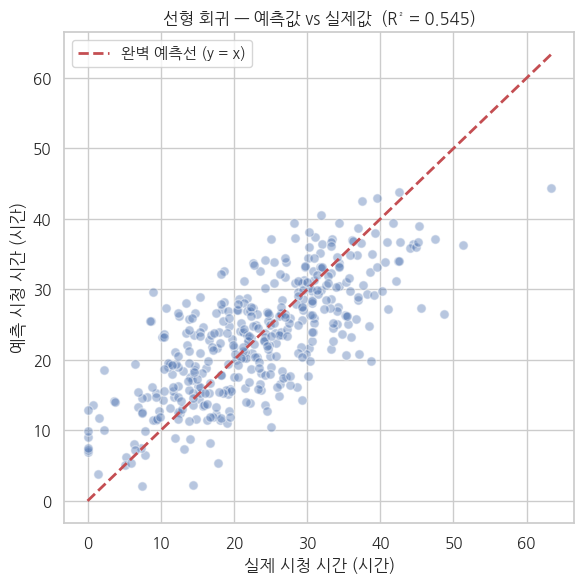

In [9]:
# ─────────────────────────────────────────────
# [C9] ◀ Part 3 · 📊 데이터로 확인해 봅시다 — 다음 달 시청 시간 예측
# 예측값 vs 실제값 — 점이 대각선에 가까울수록 잘 맞은 것
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(yr_test, yr_pred, alpha=0.4, edgecolor="w", s=45)

# 완벽 예측선 (y = x)
lims = [min(yr_test.min(), yr_pred.min()), max(yr_test.max(), yr_pred.max())]
ax.plot(lims, lims, "r--", lw=2, label="완벽 예측선 (y = x)")

ax.set_xlabel("실제 시청 시간 (시간)")
ax.set_ylabel("예측 시청 시간 (시간)")
ax.set_title(f"선형 회귀 — 예측값 vs 실제값  (R² = {r2:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

### 🎯 예상과 맞았나요? — [C8]·[C9]

> **읽는 법:** 점이 빨간 점선(완벽 예측선)에 **가까이 모일수록** 잘 맞은 것입니다. 지금은 R²가 약 **0.545**로, 흩어짐이 꽤 보입니다. "다음 달 시청 시간은 이 10개 피처만으로는 절반 조금 넘게만 설명된다"는 정직한 신호입니다 — 나쁜 게 아니라, 더 좋은 모델·피처가 필요하다는 **다음 단계의 동기**입니다.
>
> 사람의 다음 달 행동에는 우리가 가진 열로는 알 수 없는 것들이 섞여 있습니다 — 새로 올라온 화제작, 이사, 바빠진 일정. 이 "설명되지 않는 절반"은 데이터의 한계이지 모델의 실패가 아닙니다.

> 📌 **다른 산업에서는?** 선형 회귀로 **이커머스**는 광고비 대비 매출을, **부동산**은 면적·위치로 집값을, **에너지**는 기온으로 전력 수요를 예측합니다. "숫자를 예측하고 싶다"면 가장 먼저 꺼내는 베이스라인 모델입니다.

## ⌨️ 백문이 불여일타! (3)

```
[문제] 같은 모델인데 순위가 두 개입니다.
1) lin.coef_를 피처 이름과 묶어, 절댓값이 큰 순서로 정렬해 출력해보세요.
2) 이번엔 피처를 StandardScaler로 표준화한 뒤 선형 회귀를 다시 학습해,
   같은 방식으로 계수를 정렬해보세요.
3) 두 순위를 비교해보세요 — 1등이 다릅니다. 왜 그럴까요?
   어느 쪽을 "영향력 순서"라고 불러야 할까요?
```

▶ 실행: [C10]

In [10]:
# [C10] ◀ Part 3 · ⌨️ 백문이 불여일타! (3)
# ⌨️ 백문이 불여일타! (3) — 같은 모델, 두 개의 순위

from sklearn.preprocessing import StandardScaler

coef_raw = pd.Series(lin.coef_, index=FEATURES)   # 원래 단위 그대로의 계수

order = coef_raw.abs().sort_values(ascending=False).index
coef_sorted = coef_raw.reindex(order)

newdata = StandardScaler().fit_transform(Xr_train)
lin_scaled = LinearRegression()
lin_scaled.fit(newdata, yr_train)  

coef_scaled = pd.Series(lin_scaled.coef_, index=FEATURES)
order_scaled = coef_scaled.abs().sort_values(ascending=False).index
coef_scaled_sorted = coef_scaled.reindex(order_scaled)

print("[표준화 전 계수 순위]")
print(coef_sorted)
print("\n[표준화 후 계수 순위]")
print(coef_scaled_sorted)

# 표준화 전 계수는 각 피처의 측정 단위와 값의 범위에 영향을 받기 때문에 절댓값의 크기를 직접 비교하기 어려움.
# 표준화 후에는 모든 피처가 동일한 척도로 변환되므로, 각 피처가 1표준편차 증가할 때 종속변수가 얼마나 변하는지를 비교할 수 있음.
# 따라서 피처 간 상대적인 영향력 순서를 비교할 때는 표준화 후 회귀계수의 절댓값 순위가 더 적절함.

[표준화 전 계수 순위]
completion_rate           6.695976
watch_hours_last_month    0.518092
device_count              0.468640
days_since_last_watch    -0.266807
avg_session_min           0.059298
support_tickets           0.049437
tenure_months             0.036699
avg_daily_watch_min       0.021594
titles_started            0.004853
monthly_fee               0.000035
dtype: float64

[표준화 후 계수 순위]
watch_hours_last_month    5.242501
days_since_last_watch    -1.240929
avg_session_min           1.116226
completion_rate           1.061070
tenure_months             0.514012
avg_daily_watch_min       0.440254
device_count              0.424927
monthly_fee               0.133014
support_tickets           0.049317
titles_started            0.030743
dtype: float64


<details>
<summary>(클릭) 💡 힌트</summary>

- 절댓값 기준 순서는 `coef.abs().sort_values(ascending=False)`로 얻고, 부호까지 보려면 그 순서(`.index`)로 원래 계수를 `reindex(...)` 합니다.
- 표준화는 [C13]에서 쓸 패턴과 같습니다 — `StandardScaler().fit_transform(Xr_train)`으로 변환한 데이터로 `LinearRegression()`을 다시 `fit`하면 됩니다.
- 3번은 각 피처의 **값의 범위**를 떠올려보세요. `completion_rate`는 0~1 사이를 움직이고, `monthly_fee`는 9,900~19,900을 움직입니다. 같은 "1단위"가 두 열에서 같은 크기의 변화일까요?

</details>

## 학습한 모델로 "새 고객"을 예측해 봅시다

모델을 학습했으니, 이제 **처음 보는 입력**에 대해 예측값을 뽑아볼 수 있습니다. 이것이 머신러닝의 목적입니다 — 새 데이터의 답을 맞히는 것. 테스트셋의 첫 고객을 모델에 넣어 예측과 실제를 비교해 봅시다.

▶ 실행: [C11]

In [11]:
# [C11] ◀ Part 3 · 학습한 모델로 "새 고객"을 예측해 봅시다
# 새 입력(테스트셋 첫 고객)에 대한 예측 vs 실제
one = Xr_test.iloc[[0]]              # 처음 보는 고객 1명
pred_one = lin.predict(one)[0]
real_one = yr_test.iloc[0]
print(f"지난달 시청 시간 = {one['watch_hours_last_month'].iloc[0]:.1f}시간")
print(f"예측 시청 시간   = {pred_one:.1f}시간")
print(f"실제 시청 시간   = {real_one:.1f}시간")
print(f"오차(error)      = {real_one - pred_one:+.1f}시간")

지난달 시청 시간 = 14.4시간
예측 시청 시간   = 14.7시간
실제 시청 시간   = 11.8시간
오차(error)      = -2.9시간


## 오차를 들여다보기 — 잔차(Residual)

모델이 "어디서, 얼마나" 틀리는지 보려면 **잔차(residual = 실제 − 예측)** 를 그려봅니다. 좋은 회귀 모델이라면 잔차가 **0을 중심으로 무작위로 흩어져** 있어야 합니다. 한쪽으로 치우치거나 패턴이 보이면, 모델이 놓친 구조가 있다는 신호입니다.

▶ 실행: [C12]

잔차 평균 = -0.10 (0에 가까울수록 편향 없음)
잔차 표준편차 = 6.99


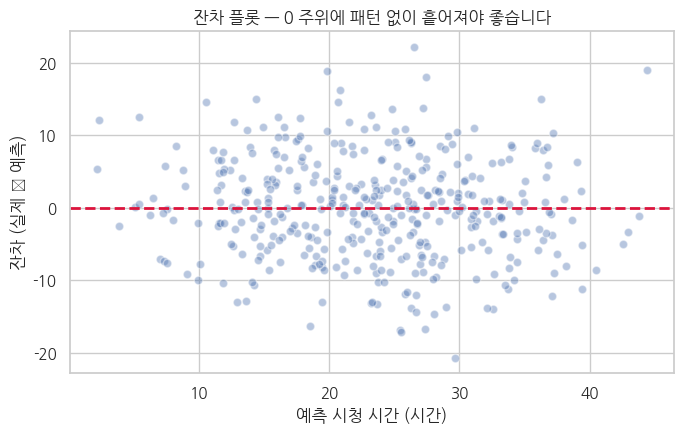

In [12]:
# ─────────────────────────────────────────────
# [C12] ◀ Part 3 · 오차를 들여다보기 — 잔차(Residual)
# 잔차 플롯 — 0 주위에 고르게 흩어질수록 좋다
# ─────────────────────────────────────────────
residuals = yr_test.values - yr_pred
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(yr_pred, residuals, alpha=0.4, edgecolor="w")
ax.axhline(0, color="crimson", ls="--", lw=2)
ax.set_xlabel("예측 시청 시간 (시간)"); ax.set_ylabel("잔차 (실제 − 예측)")
ax.set_title("잔차 플롯 — 0 주위에 패턴 없이 흩어져야 좋습니다")
plt.tight_layout(); plt.show()
print(f"잔차 평균 = {residuals.mean():.2f} (0에 가까울수록 편향 없음)")
print(f"잔차 표준편차 = {residuals.std():.2f}")

> **[C12] 읽는 법:** 점들이 빨간 0선 주위에 **구름처럼 고르게** 퍼져 있으면 건강한 신호입니다. 만약 깔때기 모양(예측이 클수록 오차가 커짐)이나 곡선 패턴이 보이면, 비선형 관계나 분산 불균형을 의심해야 합니다 — 더 나은 피처나 모델이 필요하다는 뜻입니다. 잔차 평균이 **−0.10**, 잔차 표준편차가 **6.99**로 출력됐다면 **흩어짐(6.99)에 비해 치우침(0.10)이 훨씬 작다**는 뜻이라 편향은 거의 없다고 봅니다 — "0에 가깝다"는 판단은 늘 흩어짐과 견주어 내립니다.

## 🚦 짚고 넘어가기

1. MSE에서 오차를 *제곱*하는 이유 두 가지는 무엇인가요?
2. R²가 0이라는 것은 어떤 모델과 비슷하다는 뜻인가요? R²가 음수일 수도 있나요?
3. scikit-learn 모델의 공통 두 단계는 무엇인가요? (`.____()` → `.____()`)

> 💡 **다음 Part 예고:** 선형 회귀는 *숫자*를 예측했습니다. 그런데 "이탈할까, 안 할까"처럼 *예/아니오*를 예측하려면? 직선의 출력을 0~1 확률로 누르는 영리한 트릭 — 로지스틱 회귀로 넘어갑니다.

# Part 4. 로지스틱 회귀 — 예/아니오를 예측한다

이번엔 **분류** 차례입니다. "이 고객이 이탈할까?", "이 거래가 사기일까?" 같은 **예/아니오** 질문을 다루는 첫 모델, **로지스틱 회귀(Logistic Regression)** 입니다.

> ❓ **이 파트에서 답할 질문:** 직선의 출력은 $-\infty$에서 $+\infty$까지 뻗는데, 이걸 어떻게 0~1 사이의 *확률*로 누를까?

## 💡 쉽게 말하면 — 직선의 출력을 확률로 변환하는 S자 스위치

선형 회귀의 출력 $z = w x + b$는 아무 숫자나 될 수 있습니다(−100도, +300도). 그런데 "이탈 확률"은 반드시 **0과 1 사이**여야 합니다. 그래서 출력 $z$를 **시그모이드(Sigmoid)** 라는 S자 함수에 통과시켜 0~1로 눌러줍니다.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- $\sigma$(시그마) — 시그모이드 함수
- $z$ — 선형 결합 출력 $z = w_1 x_1 + \cdots + b$
- $e$ — 자연상수(약 2.718)

읽는 법:

| $z$ 값              | $\sigma(z)$ | 해석                 |
| ------------------- | ----------- | -------------------- |
| 큰 음수 ($-\infty$) | 0에 가까움  | "거의 확실히 아니다" |
| 0                   | 정확히 0.5  | "반반, 모르겠다"     |
| 큰 양수 ($+\infty$) | 1에 가까움  | "거의 확실히 그렇다" |

즉 로지스틱 회귀는 $P(y=1 \mid x) = \sigma(w x + b)$ — **"입력 $x$일 때 정답이 1일 확률"** 을 출력합니다.

![시그모이드 곡선 — 왼쪽 아래 0에서 시작해 가운데 0.5를 지나 오른쪽 위 1로 완만하게 올라가는 S자 곡선](https://upload.wikimedia.org/wikipedia/commons/8/88/Logistic-curve.svg)

_(출처: [Logistic-curve](https://commons.wikimedia.org/wiki/File:Logistic-curve.svg) — Qef, Public domain)_

> **읽는 법:** 가로축이 선형 결합 출력 $z$, 세로축이 확률 $\sigma(z)$입니다. $z$가 0보다 크면 확률이 0.5를 넘고, 작으면 0.5 아래로 떨어집니다. 가운데(0 근처)에서 가장 가파르게 변하는데, 바로 이 가파른 구간이 "헷갈리는 경계 지대"입니다. 양쪽 끝은 0과 1에 닿을 듯 눕기만 하고 결코 넘지 않습니다 — 확률이 0~1을 벗어나지 않는 이유입니다.

## 🔍 자세히 알아보기 — 결정경계와 정확도

확률을 얻었으면 결정을 내려야 합니다. 보통 **0.5를 임계값(Threshold)** 으로 잡습니다.

- $\sigma(z) \geq 0.5$ → "1(이탈)이다"
- $\sigma(z) < 0.5$ → "0(유지)이다"

$\sigma(z)=0.5$가 되는 지점, 즉 $z = wx+b = 0$이 되는 선을 **결정경계(Decision Boundary)** 라고 합니다. 이 경계를 기준으로 한쪽은 1, 다른 쪽은 0으로 분류됩니다.

그리고 분류의 가장 기본 점수는 **정확도(Accuracy)** 입니다.

$$\text{Accuracy} = \frac{\text{맞힌 개수}}{\text{전체 개수}}$$

> ⚠️ **미리 던지는 경고:** 정확도는 직관적이지만 **클래스가 불균형하면 거짓말**을 합니다. 모두플레이의 이탈률은 0.325로 크게 기울지는 않았지만, 그래도 "전부 유지"라고 찍기만 해도 정확도가 0.675나 나옵니다 — 이 사실을 [C20]에서 직접 확인합니다. 이탈 고객이 5%뿐인 서비스라면 아무 생각 없이 찍어도 95%입니다. 이 함정과 해법(정밀도·재현율·PR곡선)은 이후 정면으로 다룹니다.

## 📊 데이터로 확인해 봅시다 — 이탈 예측

[C5]에서 나눠 둔 이탈 예측용 데이터(`X_train, y_train, X_test, y_test`)로 로지스틱 회귀를 학습시키겠습니다. 패턴은 선형 회귀와 **완전히 똑같습니다**: `.fit()` → `.predict()`.

여기서 한 가지가 추가됩니다 — **스케일 조정**입니다. 로지스틱 회귀는 피처의 크기에 민감해서, 단위가 섞인 모두플레이 데이터(개월·시간·분·원)를 그대로 넣으면 학습이 잘 되지 않습니다. `StandardScaler`로 모든 피처를 "평균 0, 표준편차 1"의 같은 자로 맞춰 줍니다.

### 🤔 예상해 볼까요?

이탈 예측 분류기를 학습합니다. 실행 전에 예상해 보세요 — 10개 피처를 쓰는 로지스틱 회귀의 **테스트 정확도**는 대략 얼마일까요? 그리고 틀린 예측은 **떠날 고객을 놓친 실수**와 **남을 고객에게 헛경보를 낸 실수** 중 어느 쪽이 더 많을까요?

▶ 실행: [C13]

In [13]:
# [C13] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 이탈 예측
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# 로지스틱 회귀는 피처 크기에 민감 → 스케일 조정 후 학습 (자세한 이유는 피처·Pipeline 시간)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # 학습 데이터로만 기준을 잡고
X_test_s = scaler.transform(X_test)         # 같은 기준으로 테스트 변환 (누수 방지!)

clf = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
clf.fit(X_train_s, y_train)

y_pred = clf.predict(X_test_s)              # 예/아니오 예측
y_proba = clf.predict_proba(X_test_s)[:, 1] # 1(이탈)일 확률

acc = accuracy_score(y_test, y_pred)
print(f"테스트 정확도(Accuracy) = {acc:.3f}")
print()
print("예측 확률 예시 (앞 5명):")
for real, p in zip(y_test[:5], y_proba[:5]):
    decision = "이탈(1)" if p >= 0.5 else "유지(0)"
    print(f"  P(이탈)={p:.3f} → {decision:8s} | 실제={real}")

테스트 정확도(Accuracy) = 0.802

예측 확률 예시 (앞 5명):
  P(이탈)=0.033 → 유지(0)    | 실제=0
  P(이탈)=0.035 → 유지(0)    | 실제=0
  P(이탈)=0.194 → 유지(0)    | 실제=0
  P(이탈)=0.128 → 유지(0)    | 실제=0
  P(이탈)=0.107 → 유지(0)    | 실제=0


정확도 숫자 하나로는 "어떻게 틀렸는지"가 보이지 않습니다. 이 분류기가 무엇을 맞히고 무엇을 놓쳤는지, **혼동행렬(Confusion Matrix)** 로 펼쳐 봅니다.

▶ 실행: [C14]

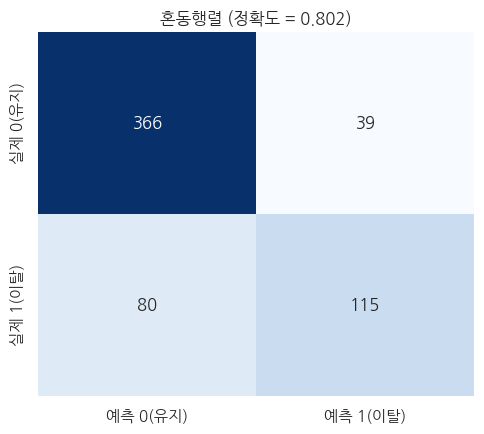

In [14]:
# ─────────────────────────────────────────────
# [C14] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 이탈 예측
# 혼동행렬 — 무엇을 맞히고 무엇을 틀렸나
# ─────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["예측 0(유지)", "예측 1(이탈)"],
            yticklabels=["실제 0(유지)", "실제 1(이탈)"], ax=ax)
ax.set_title(f"혼동행렬 (정확도 = {acc:.3f})")
plt.tight_layout()
plt.show()

### 🎯 예상과 맞았나요? — [C13]·[C14]

> **읽는 법:** 테스트 정확도는 **0.775**입니다. 대각선(왼쪽 위 ↘ 오른쪽 아래)이 **맞힌** 개수, 나머지가 **틀린** 개수입니다. 대각선 밖 두 칸을 비교하면 아까의 예상도 채점할 수 있습니다 — **떠날 고객을 놓친 것이 62명, 남을 고객에게 헛경보를 낸 것이 28명**입니다. 놓침이 헛경보의 두 배가 넘습니다.
>
> 이건 우연이 아닙니다. 이탈 고객이 소수(32.5%)라서, 모델은 애매할 때 "유지"로 기우는 편이 정확도에 유리합니다. 혼동행렬은 "그냥 정확도 한 숫자"보다 훨씬 많은 이야기를 해줍니다 — _어떤_ 실수를 했는지 보이기 때문입니다. 이 표를 깊이 읽는 법(정밀도·재현율)은 이후 배울 핵심입니다.

### 혼동행렬의 네 칸, 이름 풀이

혼동행렬의 네 칸에는 각각 이름이 있습니다. 처음엔 헷갈리지만 규칙은 단순합니다 — **"맞혔나/틀렸나"(True/False) + "무엇이라 예측했나"(Positive/Negative)** 의 조합입니다. 여기서 **양성(Positive)** 은 "모델이 1이라고 판정했다"는 뜻이고, 이 데이터에서 1은 **이탈**입니다.

| 칸             | 이름                    | 모두플레이에서는                    |
| -------------- | ----------------------- | ----------------------------------- |
| 실제 1, 예측 1 | **TP** (True Positive)  | 떠날 고객을 맞게 찍음 ✅            |
| 실제 0, 예측 0 | **TN** (True Negative)  | 남을 고객을 맞게 찍음 ✅            |
| 실제 0, 예측 1 | **FP** (False Positive) | 남을 고객에게 헛경보 (쿠폰 낭비) ❌ |
| 실제 1, 예측 0 | **FN** (False Negative) | 떠날 고객을 놓침 (고객을 잃는다) ❌ |

> 💡 **무엇이 더 치명적일까?** 모두플레이 입장에서 **떠날 고객을 놓치면**(FN) 그 고객의 남은 생애 가치를 통째로 잃습니다. 반대로 **남을 고객에게 헛경보를 내면**(FP) 필요 없는 쿠폰 한 장을 낭비합니다. 두 손실의 크기가 전혀 다릅니다 — 질병 검사에서 병을 놓치는 실수, 스팸 필터에서 정상 메일을 스팸으로 모는 실수도 마찬가지입니다. _상황마다 더 피해야 할 실수가 다르다_ — 그래서 정확도 하나로는 부족하고, 이후 정밀도·재현율로 이 둘을 따로 관리합니다.

이번엔 두 개의 피처만 써서 **결정경계**를 눈으로 봅시다. 고차원은 그릴 수 없으니, 직관을 위해 2D로 줄여 그립니다.

▶ 실행: [C15]

2피처 모델 테스트 정확도 = 0.745


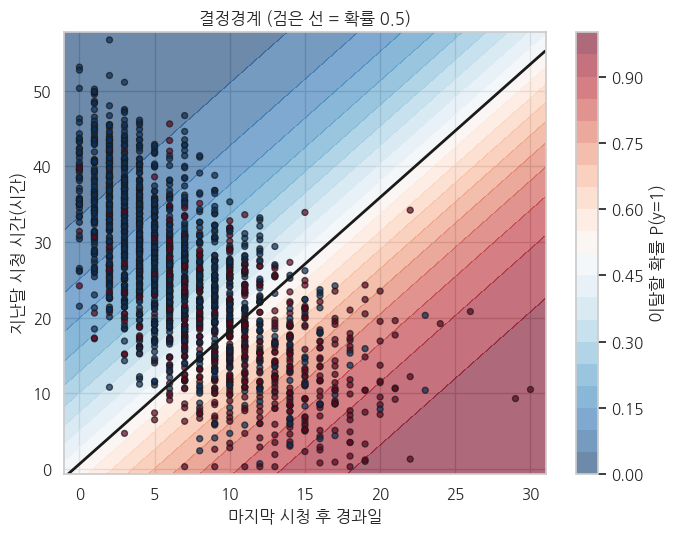

In [15]:
# ─────────────────────────────────────────────
# [C15] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 이탈 예측
# 결정경계 — 로지스틱 회귀가 두 클래스를 가르는 선
# ─────────────────────────────────────────────
# 직관을 위해 피처 2개만 사용
feat = ["days_since_last_watch", "watch_hours_last_month"]
X2 = moduplay[feat].values
X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf)

sc2 = StandardScaler().fit(X2_tr)
clf2 = LogisticRegression(random_state=RANDOM_STATE).fit(sc2.transform(X2_tr), y2_tr)

# 격자 위에서 예측 확률을 계산해 경계를 색칠
xx, yy = np.meshgrid(
    np.linspace(X2[:, 0].min()-1, X2[:, 0].max()+1, 200),
    np.linspace(X2[:, 1].min()-1, X2[:, 1].max()+1, 200))
grid = sc2.transform(np.c_[xx.ravel(), yy.ravel()])
zz = clf2.predict_proba(grid)[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 5.5))
cf = ax.contourf(xx, yy, zz, levels=20, cmap="RdBu_r", alpha=0.6)
ax.contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=2)  # 결정경계 (P=0.5)
ax.scatter(X2[:, 0], X2[:, 1], c=y_clf, cmap="RdBu_r", edgecolor="k", s=18, alpha=0.7)
plt.colorbar(cf, label="이탈할 확률 P(y=1)")
ax.set_xlabel("마지막 시청 후 경과일"); ax.set_ylabel("지난달 시청 시간(시간)")
ax.set_title("결정경계 (검은 선 = 확률 0.5)")
plt.tight_layout()
plt.show()

print(f"2피처 모델 테스트 정확도 = {clf2.score(sc2.transform(X2_te), y2_te):.3f}")

> **[C15] 읽는 법:** 검은 선이 **결정경계**(확률 0.5)입니다. 색이 진할수록 이탈 확률이 높습니다. 오른쪽 아래(오래 안 봤고 시청 시간도 적은 구역)가 이탈 쪽, 왼쪽 위(최근에 많이 본 구역)가 유지 쪽입니다. 두 무리가 완전히 갈리지 않고 **경계 부근에서 섞여 있다**는 점을 보세요 — 그래서 2피처 정확도가 0.745에 머무릅니다. 현실 데이터는 원래 이렇게 겹칩니다.
>
> 그리고 로지스틱 회귀의 경계는 **직선**입니다(그래서 "선형" 분류기). 곡선 경계가 필요한 복잡한 문제는 다음 시간의 트리·앙상블이 해결합니다.

> 📌 **다른 산업에서는?** 로지스틱 회귀는 **금융**의 부도/정상 판별, **마케팅**의 클릭/비클릭 예측, **헬스케어**의 질병 유무 진단처럼 "예/아니오"가 핵심인 곳마다 쓰입니다. 단순하고 빠르며 **확률과 함께 해석까지** 주기에 지금도 현업 베이스라인의 표준입니다.

## 로지스틱 회귀의 숨은 선물 — 계수를 "배수"로 해석

로지스틱 회귀가 단순한데도 현업에서 사랑받는 이유 하나는 **계수를 해석할 수 있다**는 점입니다. 먼저 용어 하나만 짚습니다 — **오즈(Odds)** 는 "일어날 확률 ÷ 일어나지 않을 확률"입니다. 확률이 0.5면 오즈는 1(반반), 확률이 0.9면 오즈는 9입니다.

계수 $w$에 지수를 취한 $e^{w}$ 를 **오즈비(Odds Ratio)** 라고 하며, "그 피처가 1단위(표준화했으니 1 표준편차) 커질 때 **오즈가 몇 배**가 되는가"를 뜻합니다.

- $e^{w} > 1$ → 그 피처가 클수록 **이탈(1) 쪽**으로 밀림
- $e^{w} < 1$ → 그 피처가 클수록 **유지(0) 쪽**으로 밀림

> ⚠️ **주의:** 오즈비는 *확률*이 몇 배가 되는지가 아니라 *오즈*가 몇 배가 되는지입니다. "2.1배"를 "확률이 2.1배"로 읽으면 틀립니다.

[C15]에서 쓴 2피처 모델(`clf2`)의 계수를 읽어 봅시다.

▶ 실행: [C16]

In [16]:
# [C16] ◀ Part 4 · 로지스틱 회귀의 숨은 선물 — 계수를 "배수"로 해석
# [C15]의 2피처 모델 계수 → 오즈비(exp)로 변환해 방향과 크기 읽기
odds2 = pd.Series(np.exp(clf2.coef_[0]), index=feat)

print("오즈비(Odds Ratio) — 피처가 1 표준편차 커질 때 이탈 오즈가 몇 배가 되나")
for name, v in odds2.items():
    direction = "이탈(1) 쪽" if v > 1 else "유지(0) 쪽"
    print(f"  {name:24s}: x{v:6.3f}  → 값이 클수록 {direction}")
print("\n→ 오래 안 볼수록 이탈 쪽으로, 많이 볼수록 유지 쪽으로 밀립니다.")

오즈비(Odds Ratio) — 피처가 1 표준편차 커질 때 이탈 오즈가 몇 배가 되나
  days_since_last_watch   : x 2.110  → 값이 클수록 이탈(1) 쪽
  watch_hours_last_month  : x 0.398  → 값이 클수록 유지(0) 쪽

→ 오래 안 볼수록 이탈 쪽으로, 많이 볼수록 유지 쪽으로 밀립니다.


> **[C16] 읽는 법:** 마지막 시청 후 경과일의 오즈비는 **2.11**, 지난달 시청 시간의 오즈비는 **0.398**입니다. 경과일이 1 표준편차(약 4.6일) 늘면 이탈 오즈가 2배 넘게 뛰고, 시청 시간이 1 표준편차(약 10시간) 늘면 이탈 오즈가 0.4배로 줄어듭니다. **"오래 안 볼수록 떠나고, 많이 볼수록 남는다"** — 상식과 방향이 맞습니다. 모델이 엉뚱한 것을 배우지 않았다는 첫 확인입니다.

> ⚠️ **왜 10개 피처를 다 쓴 모델로는 이걸 안 했을까요?** 모두플레이의 피처 중 `watch_hours_last_month`(지난달 총 시청 시간)와 `avg_daily_watch_min`(일평균 시청 분)은 **사실상 같은 정보를 다르게 잰 것**입니다 — 둘의 상관은 0.995입니다. 이렇게 닮은 피처가 함께 들어가면 계수들이 **영향력을 서로 나눠 갖습니다.**
>
> | 모델                  | `watch_hours` 계수 | `avg_daily` 계수 |
> | --------------------- | ------------------ | ---------------- |
> | 각각 단독으로 넣을 때 | −1.394             | −1.388           |
> | 둘을 함께 넣을 때     | **−0.836**         | **−0.564**       |
>
> 단독일 때는 각각 −1.39로 똑같이 강한데, 함께 넣으면 −0.84와 −0.56으로 쪼개집니다. 예측 성능은 그대로인데 _계수 해석만_ 믿을 수 없게 되는 것입니다("이 피처의 영향력은 −0.56"이라고 말하면 절반만 말한 셈입니다). 그래서 "계수로 설명하겠다"면 피처를 골라 단순한 모델로 봐야 합니다. 이 문제와 피처를 고르는 법은 **피처·Pipeline 시간**에 다룹니다.

> 💡 **왜 중요할까:** 트리·딥러닝 같은 복잡한 모델은 성능은 높아도 "왜 그렇게 예측했는지" 설명이 어렵습니다(블랙박스). 로지스틱 회귀는 이렇게 **계수로 바로 설명**되기에, 규제 산업(금융 신용평가·의료)에서 여전히 1순위로 쓰입니다. 모델 해석은 이후 SHAP으로 본격적으로 다룹니다.

## ➕ 더 알고 싶다면 — 사실 이 모델에는 이미 브레이크가 걸려 있습니다

한 가지 짚고 넘어갈 것이 있습니다. `LinearRegression`과 `LogisticRegression`을 나란히 배웠지만, 둘은 **기본 설정이 다릅니다.**

| 모델                 | scikit-learn 기본값                                                   |
| -------------------- | --------------------------------------------------------------------- |
| `LinearRegression`   | 아무 제약 없음 — 데이터에 가장 잘 맞는 계수를 그대로 찾습니다         |
| `LogisticRegression` | **계수가 너무 커지지 않게 누르는 장치가 이미 켜져 있습니다**(`C=1.0`) |

이 장치를 **규제(Regularization)** 라고 합니다. 계수가 커질수록 벌점을 매겨 모델이 과하게 복잡해지는 것을 막는데, 우리가 `[C13]`에서 아무것도 지정하지 않고 `LogisticRegression(max_iter=5000)`이라고만 썼을 때 이미 작동하고 있었습니다.

지금은 **"기본값이 이미 나를 한 번 보호하고 있었다"** 정도만 알아 두면 충분합니다. 규제가 무엇을 어떻게 억제하는지, 그리고 `C` 값을 직접 돌리면 무슨 일이 벌어지는지는 **과적합·교차검증 시간**에 정면으로 다룹니다.

> 💡 이것이 Part 5의 처방 표에서 만날 **"규제"** 의 정체입니다.

## ⌨️ 백문이 불여일타! (4)

```
[문제]
1) 분류 임계값을 0.5 대신 0.3으로 낮춰, y_proba로 예측을 다시 만들어보세요.
2) 임계값 0.5일 때와 0.3일 때의 혼동행렬을 각각 출력해 네 칸을 비교해보세요.
   → 놓침(실제 1을 0으로)과 헛경보(실제 0을 1로)는 각각 어떻게 변했나요?
3) 두 경우의 정확도도 함께 출력해보세요. 예상과 같나요?
```

▶ 실행: [C17]

정확도(임계값 0.5) = 0.802
정확도(임계값 0.3) = 0.767

[임계값 0.5 혼동행렬]
[[366  39]
 [ 80 115]]

[임계값 0.3 혼동행렬]
[[306  99]
 [ 41 154]]

놓침(FN): 80 → 41
헛경보(FP): 39 → 99


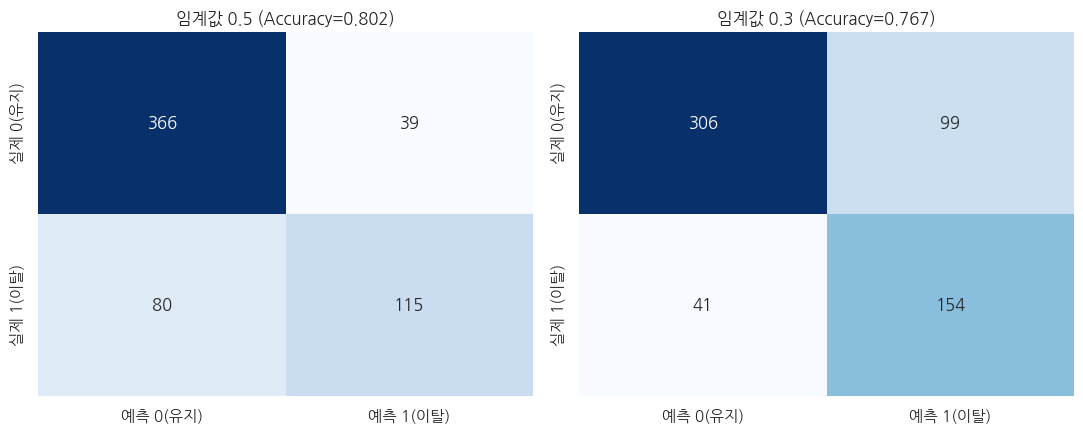

In [17]:
# [C17] ◀ Part 4 · ⌨️ 백문이 불여일타! (4)
# ⌨️ 백문이 불여일타! (4) — 임계값 0.3으로 다시 분류하고 네 칸을 비교

threshold = 0.3

threshold = 0.3

# 표준화 → 학습
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
clf.fit(X_train_s, y_train)

# 임계값 0.5와 0.3으로 각각 예측
y_proba = clf.predict_proba(X_test_s)[:, 1]
y_pred_05 = (y_proba >= 0.5).astype(int)
y_pred_03 = (y_proba >= threshold).astype(int)

# 정확도
acc_05 = accuracy_score(y_test, y_pred_05)
acc_03 = accuracy_score(y_test, y_pred_03)

print(f"정확도(임계값 0.5) = {acc_05:.3f}")
print(f"정확도(임계값 0.3) = {acc_03:.3f}")

# 혼동행렬
cm_05 = confusion_matrix(y_test, y_pred_05)
cm_03 = confusion_matrix(y_test, y_pred_03)

print("\n[임계값 0.5 혼동행렬]")
print(cm_05)
print("\n[임계값 0.3 혼동행렬]")
print(cm_03)

# 놓침(FN)과 헛경보(FP) 비교
print(f"\n놓침(FN): {cm_05[1,0]} → {cm_03[1,0]}")
print(f"헛경보(FP): {cm_05[0,1]} → {cm_03[0,1]}")

# 시각화
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

sns.heatmap(cm_05, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["예측 0(유지)", "예측 1(이탈)"],
            yticklabels=["실제 0(유지)", "실제 1(이탈)"], ax=ax[0])

sns.heatmap(cm_03, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["예측 0(유지)", "예측 1(이탈)"],
            yticklabels=["실제 0(유지)", "실제 1(이탈)"], ax=ax[1])

ax[0].set_title(f"임계값 0.5 (Accuracy={acc_05:.3f})")
ax[1].set_title(f"임계값 0.3 (Accuracy={acc_03:.3f})")

plt.tight_layout()
plt.show()

<details>
<summary>(클릭) 💡 힌트</summary>

- 임계값을 낮춘다는 것은 "조금만 그럼직해도 1로 본다"는 뜻입니다 — 1 예측이 늘어납니다.
- 새 예측은 `(y_proba >= threshold).astype(int)`처럼 확률을 직접 잘라 만들 수 있습니다.
- 혼동행렬은 `confusion_matrix(y_test, 예측)`으로 두 번 각각 출력해 나란히 놓고 비교하세요.

</details>

> 💡 혼동행렬이 보여주듯 "어떤 실수인지"는 정확도 하나로 안 보입니다. 정밀도·재현율·PR곡선으로 이를 정면으로 다루는 날이 곧 옵니다 — **분류 지표·불균형 시간**입니다.

## 🚦 짚고 넘어가기

1. 시그모이드 함수는 왜 필요한가요? $z=0$일 때 출력은 얼마인가요?
2. 결정경계란 무엇이며, 로지스틱 회귀에서는 왜 직선 모양인가요?
3. 정확도가 높아도 그대로 믿으면 안 되는 상황(불균형)은 어떤 경우인가요?

> 💡 **다음 Part 예고:** 지금까지 테스트 데이터로 점수를 쟀습니다. 그런데 *학습 데이터*에서의 점수와 비교하면 모델의 숨은 성격이 드러납니다. "이 성능, 정말 믿어도 될까?"를 따지는 마지막 Part입니다.

# Part 5. 이 성능, 믿어도 될까?

이 모듈을 관통하는 가장 중요한 태도 하나를 소개합니다. **"성능 숫자 하나를 그대로 믿지 않는다."** 통계 모듈에서 "p-value 하나로 끝내지 않는다"를 배웠듯, 머신러닝에서는 **"정확도 하나로 끝내지 않습니다."**

> ❓ **이 파트에서 답할 질문:** 좋아 보이는 점수가 *진짜 실력*인지, 아니면 *외운 답*인지 어떻게 구별할까?

## 💡 쉽게 말하면 — 족보 외운 학생 다시 보기

Part 2에서 본 "시험 문제 미리 본 학생"을 다시 떠올려 봅시다. 그 학생의 정체를 드러내는 방법은 간단합니다. **공부한 문제(학습 데이터)와 새 문제(테스트 데이터)의 점수를 나란히 비교**하면 됩니다.

| 학습 점수 | 테스트 점수 | 진단                                |
| --------- | ----------- | ----------------------------------- |
| 높음      | 높음        | 👍 잘 일반화됨 (좋은 모델)          |
| **높음**  | **낮음**    | ⚠️ **과적합(Overfitting)** — 외웠다 |
| 낮음      | 낮음        | 😵 과소적합 — 아직 덜 배웠다        |

가운데 줄이 핵심입니다. **학습 점수만 높고 테스트 점수가 뚝 떨어지면 "과적합"** — 모델이 패턴이 아니라 잡음까지 외워버린 상태입니다. 이 진단과 처방(규제·교차검증)이 바로 이후 배울 주제입니다. 오늘은 **"두 점수를 꼭 비교한다"** 는 습관을 들이는 게 목표입니다.

## 🔍 자세히 알아보기 — 과적합·과소적합을 무엇으로 판정하나

"과적합"은 느낌이 아니라 **두 숫자의 관계**로 판정합니다.

- **일반화(Generalization)** — 학습에서 본 적 없는 새 데이터에서도 성능이 유지되는 능력. 머신러닝이 궁극적으로 원하는 것입니다.
- **일반화 격차(Generalization Gap)** — 학습 점수와 테스트 점수의 차이입니다.

$$\text{일반화 격차} = (\text{학습 점수}) - (\text{테스트 점수})$$

- 학습 점수 — 모델이 _보고 배운_ 데이터에서의 점수
- 테스트 점수 — 모델이 _한 번도 못 본_ 데이터에서의 점수

격차 자체가 나쁜 것은 아닙니다. 문제는 **격차가 클 때**입니다.

| 상태                   | 학습 점수 | 테스트 점수 | 격차   | 원인                              | 처방                   |
| ---------------------- | --------- | ----------- | ------ | --------------------------------- | ---------------------- |
| 과소적합(Underfitting) | 낮음      | 낮음        | 작음   | 모델이 너무 단순해 패턴을 못 잡음 | 복잡도↑, 피처 추가     |
| 적정                   | 높음      | 높음        | 작음   | —                                 | 유지                   |
| 과적합(Overfitting)    | 매우 높음 | 낮음        | **큼** | 패턴이 아니라 잡음까지 외움       | 복잡도↓, 규제, 데이터↑ |

> ⚠️ **주의:** "격차가 몇 이상이면 과적합"이라는 절대 기준은 없습니다. 데이터 크기·문제 난이도·지표 종류에 따라 다르므로, **같은 문제 안에서 여러 설정을 비교**해 판단합니다. 오늘 익힐 것은 숫자 기준이 아니라 *두 점수를 항상 나란히 본다*는 습관입니다.

> 💡 **개념 연결:** Part 2의 `train_test_split`이 바로 이 판정을 가능하게 만든 장치입니다. 테스트셋을 끝까지 아껴 두지 않으면 격차를 잴 자가 없어집니다.

> 📌 **다른 산업에서는?** 이 격차 점검은 **금융**의 부도 예측 모델 검증, **제조**의 불량 예측 설비 이관, **헬스케어**의 진단 모델 외부 검증에서 배포 전 필수 관문으로 쓰입니다.

### 🤔 예상해 볼까요?

Part 3의 선형 회귀(시청 시간)와 Part 4의 로지스틱(이탈)에 대해 **학습 점수와 테스트 점수**를 나란히 재 봅니다. 실행 전에 예상해 보세요 — 오늘처럼 _단순한_ 모델들에서 두 점수의 격차는 클까요, 작을까요?

▶ 실행: [C18]

## 📊 데이터로 확인해 봅시다 — 학습 점수 vs 테스트 점수

두 모델(선형 회귀, 로지스틱 회귀)의 학습/테스트 점수를 나란히 출력해 보겠습니다.

▶ 실행: [C18]

In [18]:
# [C18] ◀ Part 5 · 📊 데이터로 확인해 봅시다 — 학습 점수 vs 테스트 점수
# 선형 회귀(시청 시간): 학습 R² vs 테스트 R²
r2_train = lin.score(Xr_train, yr_train)
r2_test = lin.score(Xr_test, yr_test)

# 로지스틱 회귀(이탈): 학습 정확도 vs 테스트 정확도
acc_train = clf.score(X_train_s, y_train)
acc_test = clf.score(X_test_s, y_test)

summary = pd.DataFrame({
    "모델": ["선형회귀 (R²)", "로지스틱회귀 (Accuracy)"],
    "학습 점수": [r2_train, acc_train],
    "테스트 점수": [r2_test, acc_test],
})
summary["차이(학습-테스트)"] = summary["학습 점수"] - summary["테스트 점수"]
print(summary.round(3).to_string(index=False))

               모델  학습 점수  테스트 점수  차이(학습-테스트)
        선형회귀 (R²)  0.590   0.545       0.045
로지스틱회귀 (Accuracy)  0.789   0.802      -0.013


같은 비교를 이번엔 눈으로 — 두 점수를 나란히 막대로 세워 격차를 확인합니다.

▶ 실행: [C19]

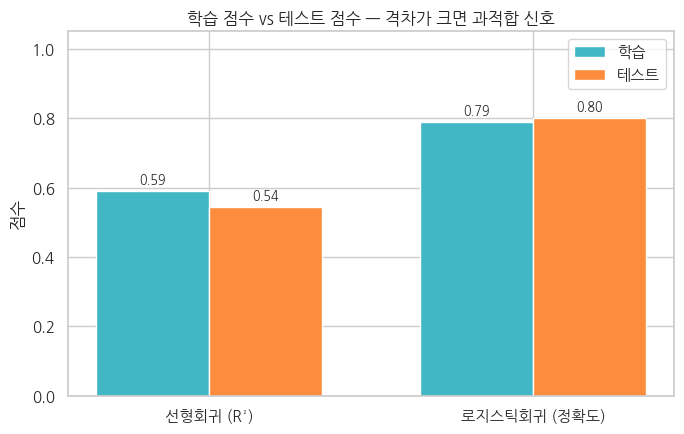

In [19]:
# ─────────────────────────────────────────────
# [C19] ◀ Part 5 · 📊 데이터로 확인해 봅시다 — 학습 점수 vs 테스트 점수
# 학습 vs 테스트 점수 — 격차가 크면 과적합 신호
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(summary))
w = 0.35
ax.bar(x - w/2, summary["학습 점수"], w, label="학습", color="#41b6c4")
ax.bar(x + w/2, summary["테스트 점수"], w, label="테스트", color="#fd8d3c")
ax.set_xticks(x); ax.set_xticklabels(["선형회귀 (R²)", "로지스틱회귀 (정확도)"])
ax.set_ylabel("점수"); ax.set_ylim(0, 1.05)
ax.set_title("학습 점수 vs 테스트 점수 — 격차가 크면 과적합 신호")
ax.legend()
for i, (tr, te) in enumerate(zip(summary["학습 점수"], summary["테스트 점수"])):
    ax.text(i - w/2, tr + 0.02, f"{tr:.2f}", ha="center", fontsize=9)
    ax.text(i + w/2, te + 0.02, f"{te:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### 🎯 예상과 맞았나요? — [C18]·[C19]

> **읽는 법:** 두 막대의 **높이 차이**가 작을수록 모델이 잘 일반화된 것입니다. 선형 회귀는 학습 0.590 대 테스트 0.545(격차 0.045), 로지스틱은 학습 0.799 대 테스트 0.775(격차 0.024)로 **둘 다 격차가 작아 건강합니다.** 오늘 쓴 모델이 단순해서 애초에 외울 여력이 없었기 때문입니다. 만약 학습 막대만 천장에 닿고 테스트 막대가 푹 꺼졌다면, 그게 바로 과적합의 그림입니다.

> 💡 **이 성능, 믿어도 될까? (평가 박스):** 앞으로 모델을 만들 때마다 스스로 이 세 가지를 물으세요 — ① 학습/테스트를 제대로 나눴나? ② 문제 맥락에 맞는 지표인가(불균형이면 정확도만으론 부족)? ③ 학습 점수와 테스트 점수의 격차는 괜찮은가(과적합)? 이 습관이 이 모듈 전체의 뼈대입니다.

## 베이스라인과 비교 — 우리 모델이 "찍기"보다 나은가?

성능 숫자는 **기준선(Baseline)** 과 비교해야 의미가 생깁니다. "정확도 0.80"도 무조건 다수 클래스로 찍은 베이스라인이 0.79라면 거의 의미가 없습니다. scikit-learn의 `DummyClassifier`/`DummyRegressor`가 이 "아무 생각 없는 기준선"을 만들어 줍니다.

▶ 실행: [C20]

In [20]:
# ─────────────────────────────────────────────
# [C20] ◀ Part 5 · 베이스라인과 비교 — 우리 모델이 "찍기"보다 나은가?
# 베이스라인(Dummy) — "찍기"와 나란히 세우기
# ─────────────────────────────────────────────
from sklearn.dummy import DummyClassifier, DummyRegressor

# (분류·이탈) 무조건 다수 클래스로 찍는 베이스라인 vs 로지스틱 회귀
dum_clf = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
base_acc = dum_clf.score(X_test, y_test)   # Dummy는 X 값을 무시하므로 스케일링 불필요
print("[분류·이탈 예측]")
print(f"  베이스라인(무조건 다수) 정확도 = {base_acc:.3f}")
print(f"  로지스틱 회귀 테스트 정확도    = {acc_test:.3f}")
print(f"  → 모델이 베이스라인보다 {acc_test - base_acc:+.3f} 만큼 낫다")

# (회귀·시청 시간) 무조건 평균으로 찍는 베이스라인 vs 선형 회귀 (R² 기준)
dum_reg = DummyRegressor(strategy="mean").fit(Xr_train, yr_train)
base_r2 = dum_reg.score(Xr_test, yr_test)
print("\n[회귀·다음 달 시청 시간]")
print(f"  베이스라인(평균 예측) R² = {base_r2:.3f}  (정의상 ~0)")
print(f"  선형회귀 테스트 R²       = {r2_test:.3f}")
print(f"  → 평균 찍기보다 {r2_test - base_r2:+.3f} 만큼 더 설명한다")

[분류·이탈 예측]
  베이스라인(무조건 다수) 정확도 = 0.675
  로지스틱 회귀 테스트 정확도    = 0.802
  → 모델이 베이스라인보다 +0.127 만큼 낫다

[회귀·다음 달 시청 시간]
  베이스라인(평균 예측) R² = -0.001  (정의상 ~0)
  선형회귀 테스트 R²       = 0.545
  → 평균 찍기보다 +0.546 만큼 더 설명한다


> 💡 **항상 베이스라인을 먼저:** "이 모델 성능 0.8"이라는 말은 _그 자체로는_ 좋다 나쁘다를 알 수 없습니다.
> **"아무 생각 없이 찍기보다 얼마나 나은가"** 가 진짜 성능입니다. 분류는 `most_frequent`, 회귀는 `mean`이 출발 기준선입니다.

> 💡 모델을 일부러 점점 복잡하게 만들면 학습-테스트 격차가 어떻게 벌어지는지 — 과적합이 *탄생하는 장면*은 **과적합·교차검증 시간**에 실험으로 정면 돌파합니다.

## ⌨️ 백문이 불여일타! (5)

```
[문제]
1) 베이스라인에도 여러 전략이 있습니다. DummyClassifier의 strategy를
   "most_frequent" / "stratified" / "uniform" 세 가지로 각각 학습해
   테스트 정확도를 나란히 출력해보세요.
   (stratified·uniform은 무작위성이 있으니 random_state=RANDOM_STATE를 주세요)
2) 세 값 중 가장 높은 것은 무엇인가요? 그 값을 테스트셋의 유지 비율
   (1 - y_test.mean())과 비교해보세요 — 무슨 관계가 보이나요?
3) 우리 로지스틱 회귀(acc_test)가 "베이스라인을 넘었다"고 말할 때,
   세 전략 중 어느 것을 기준으로 삼아야 정직한 비교일까요?
```

▶ 실행: [C21]

In [21]:
# [C21] ◀ Part 5 · ⌨️ 백문이 불여일타! (5)
# ⌨️ 백문이 불여일타! (5) — 베이스라인 전략 3종 비교, 기준을 어느 것으로 잡을까

from sklearn.dummy import DummyClassifier

strategies = ["most_frequent", "stratified", "uniform"]
scores = {}

# 1. 세 가지 베이스라인 정확도
for strategy in strategies:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    dummy.fit(X_train, y_train)
    scores[strategy] = dummy.score(X_test, y_test)

print("[DummyClassifier 정확도]")
for strategy, score in scores.items():
    print(f"{strategy:15s} = {score:.3f}")

# 2. 가장 높은 베이스라인과 테스트셋 유지 비율 비교
best_strategy = max(scores, key=scores.get)
best_score = scores[best_strategy]
retain_ratio = 1 - y_test.mean()

print(f"\n가장 높은 베이스라인 = {best_strategy} ({best_score:.3f})")
print(f"테스트셋 유지 비율    = {retain_ratio:.3f}")

# 3. 로지스틱 회귀와 가장 강한 베이스라인 비교
print(f"\n로지스틱 회귀 정확도 = {acc_test:.3f}")
print(f"최고 베이스라인       = {best_score:.3f}")
print(f"차이                  = {acc_test - best_score:+.3f}")

[DummyClassifier 정확도]
most_frequent   = 0.675
stratified      = 0.538
uniform         = 0.495

가장 높은 베이스라인 = most_frequent (0.675)
테스트셋 유지 비율    = 0.675

로지스틱 회귀 정확도 = 0.802
최고 베이스라인       = 0.675
차이                  = +0.127


<details>
<summary>(클릭) 💡 힌트</summary>

- `for st in strategies:` 로 돌면서 매번 `DummyClassifier(strategy=st, random_state=RANDOM_STATE)`를 만들어 `.fit(X_train, y_train)` → `.score(X_test, y_test)` 하면 됩니다.
- `most_frequent`는 "항상 다수 클래스만 찍기", `stratified`는 "학습 데이터의 클래스 비율대로 무작위 찍기", `uniform`은 "클래스를 균등 확률로 무작위 찍기"입니다.
- 2번은 `y_test.mean()`을 함께 출력해 눈으로 대조하세요.

</details>

## 그래서, 과적합은 어떻게 줄일까요? (미리 보기)

오늘은 과적합을 *발견*하는 법(학습 vs 테스트 비교)까지 배웠습니다. 그럼 어떻게 _줄일까요_? 미리 큰 그림만 그려두겠습니다 — 모두 다음 시간들에서 직접 다룹니다.

| 처방                           | 핵심 아이디어                                             | 어디서 배우나        |
| ------------------------------ | --------------------------------------------------------- | -------------------- |
| **규제(Regularization)**       | 모델이 너무 복잡해지지 않게 *벌점*을 준다 (Ridge·Lasso)   | 과적합·교차검증 시간 |
| **교차검증(Cross-Validation)** | 한 번의 운 좋은/나쁜 분할에 속지 않게 _여러 번_ 나눠 평가 | 과적합·교차검증 시간 |
| **더 많은/좋은 데이터·피처**   | 외울 거리를 줄이고 진짜 패턴을 준다                       | 피처·Pipeline 시간   |
| **모델 복잡도 조절**           | 트리 깊이·규제 강도 같은 *하이퍼파라미터*를 튜닝          | 피처·Pipeline 시간   |

> 💡 핵심은 단순합니다 — **"모델이 데이터를 외우지 못하게, 적당히 단순하게 유지한다."**

## 🚦 짚고 넘어가기

1. "학습 점수는 높은데 테스트 점수가 낮다"는 어떤 상태이며, 무엇이라 부르나요?
2. 과소적합과 과적합은 학습/테스트 점수 패턴이 각각 어떻게 다른가요?
3. "정확도 하나로 끝내지 않는다"는 태도는 통계 모듈의 어떤 원칙을 계승한 것일까요?

> 💡 **다음 Part 예고:** 개념 여정은 여기까지입니다. 이제 오늘의 퀴즈로 배운 것을 점검하고, **실습 노트북**으로 넘어가 진짜 비즈니스 데이터에 오늘의 루프를 통째로 적용합니다 — 그 산출물이 여러분의 *첫 모델 카드 v1*입니다.

# ❓ 오늘의 퀴즈

배운 내용을 잠깐 확인해보겠습니다. 틀려도 괜찮습니다.

## 개념 퀴즈

1. "다음 분기 매출액(원)"을 예측하는 것은 회귀일까요 분류일까요? "이 거래가 사기인지 아닌지"는요?
2. R²가 0.0인 모델은 어떤 모델과 성능이 같다는 뜻인가요?
3. 시그모이드 함수 $\sigma(z)$에서 $z=0$이면 출력은 얼마이고, 그것은 무슨 의미인가요?
4. 학습 정확도 0.99, 테스트 정확도 0.71인 모델을 어떻게 진단하겠습니까?
5. 모두플레이의 이탈률은 0.325입니다. "우리 이탈 예측 모델 정확도가 0.67입니다"라는 보고를 받았다면, 무엇을 먼저 확인해야 할까요?

## 코드 퀴즈

[C22]의 빈칸(`____`)을 채워, 모두플레이 데이터에 로지스틱 회귀를 학습시키고 **테스트 정확도**를 출력하세요.

▶ 실행: [C22]

In [22]:
# [C22] ◀ ❓ 오늘의 퀴즈 · 코드 퀴즈
# 코드 퀴즈 — 빈칸(____)을 채워 로지스틱 회귀 학습·평가
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# (X_train_s, X_test_s, y_train, y_test는 [C13]에서 준비한 그대로입니다)
quiz_model = LogisticRegression(max_iter=5000, random_state=42)
quiz_model.fit(X_train_s, y_train)          # 학습
pred = quiz_model.predict(X_test_s)             # 예측
print("테스트 정확도:", accuracy_score(y_test, pred))   # 평가

테스트 정확도: 0.8016666666666666


# 🎓 오늘의 정리

## 오늘 배운 것이 어떻게 이어지나요?

```text
[Part 1] 지도학습 — 회귀 vs 분류
   ↓ 타겟이 숫자냐 범주냐
[Part 2] 학습-평가 파이프라인 (train_test_split)
   ↓ 테스트는 끝까지 안 본다
[Part 3] 선형 회귀 (MSE·R²)            ── 숫자 예측
[Part 4] 로지스틱 회귀 (sigmoid·결정경계) ── 예/아니오 예측
   ↓ 점수 하나로 끝내지 않는다
[Part 5] 이 성능, 믿어도 될까? (학습 vs 테스트)
   ↓
[실습 노트북] 진짜 데이터로 첫 모델 카드 v1
   ↓ 다음 시간으로
한 모델로 부족하다면? → 여러 모델을 모은다 (트리·앙상블)
```

## 한 장 정리

| 개념               | 한 줄 요약                                                             |
| ------------------ | ---------------------------------------------------------------------- |
| 지도학습           | (문제 X, 정답 y) 쌍을 보고 새 문제의 답을 예측                         |
| 회귀 / 분류        | 타겟이 숫자면 회귀("얼마나"), 범주면 분류("어느 쪽")                   |
| `train_test_split` | 본 문제로 채점하면 안 됨 → 테스트는 따로 떼어 둠                       |
| 선형 회귀          | $\hat{y}=wx+b$. 평가는 MSE(작을수록 좋음)·R²(1에 가까울수록 좋음)      |
| 로지스틱 회귀      | 시그모이드 $\sigma(z)$로 확률 출력. 0.5 임계값으로 분류. 평가는 정확도 |
| 결정경계           | $\sigma(z)=0.5$가 되는 경계. 로지스틱은 직선                           |
| 과적합 점검        | 학습 점수 ≫ 테스트 점수 → 외운 것(과적합) 의심                         |

## 진단 → 다음 분석 도구 매핑

| 오늘 만난 신호                                 | 자연스러운 다음 도구 |
| ---------------------------------------------- | -------------------- |
| 직선/평면으로는 패턴이 안 잡힌다 (복잡한 경계) | 의사결정나무·앙상블  |
| 학습 점수만 높고 테스트가 낮다 (과적합)        | 규제·교차검증        |
| 정확도가 불균형에 속는다                       | 정밀도·재현율·PR곡선 |
| 피처가 부실해 R²가 낮다                        | 피처 엔지니어링·PCA  |

## 오늘 익힌 scikit-learn 공통 패턴

오늘 다룬 모든 모델은 **똑같은 패턴**으로 움직였습니다. 모델 이름만 바꾸면 그대로 재사용할 수 있습니다 — 이후 트리·앙상블도 동일합니다.

```python
from sklearn.linear_model import LinearRegression   # 또는 LogisticRegression 등

model = LinearRegression()        # 1) 모델 생성
model.fit(X_train, y_train)       # 2) 학습 (학습 데이터로만!)
pred  = model.predict(X_test)     # 3) 예측 (처음 보는 데이터)
score = model.score(X_test, y_test)  # 4) 평가 (회귀=R², 분류=정확도)
```

> 💡 **이 4줄이 머신러닝의 80%입니다.** 모델이 아무리 복잡해져도 `생성 → fit → predict → score`라는 골격은 변하지 않습니다. 오늘 이 패턴에 익숙해진 것이 가장 큰 수확입니다.

## 🙋 자주 묻는 질문 (FAQ)

**Q1. 선형 회귀와 로지스틱 회귀, 둘 다 "회귀"인데 왜 하나는 분류인가요?**
A. 이름은 역사적 이유로 둘 다 "회귀"지만, **하는 일**이 다릅니다. 선형 회귀는 *숫자*를 예측하고(회귀), 로지스틱 회귀는 그 숫자를 시그모이드로 *확률*로 바꿔 *범주*를 예측합니다(분류). 헷갈리면 "출력이 숫자냐 범주냐"로 판단하세요.

**Q2. 테스트 점수가 학습 점수보다 _높게_ 나왔습니다. 이상한가요?**
A. 데이터가 적을 때 우연히 그럴 수 있습니다. 큰 격차가 아니라면 정상 범위입니다. 다만 테스트가 _계속_ 더 높다면 분할이나 누수를 점검하세요.

**Q3. R²가 음수입니다. 버그인가요?**
A. 버그가 아닙니다. R²가 음수면 "그냥 평균으로 찍는 것보다도 못하다"는 뜻입니다. 피처가 타겟과 관계가 거의 없거나, 테스트 분포가 학습과 많이 다를 때 생깁니다.

**Q4. 왜 매번 `random_state=42`를 쓰나요? 42가 특별한가요?**
A. 숫자 자체는 아무 의미 없습니다(개발자들의 농담입니다). 중요한 건 *고정*해서 **누가 실행해도 같은 결과**가 나오게 하는 것입니다. 어떤 숫자든 괜찮습니다.

## 📖 핵심 용어 사전

| 용어              | 한 줄 정의                                                        |
| ----------------- | ----------------------------------------------------------------- |
| 머신러닝          | 데이터에서 패턴을 학습해 아직 보지 못한 데이터의 답을 맞히는 도구 |
| 지도학습          | (입력 X, 정답 y) 쌍으로 규칙을 배워 새 입력의 y를 예측            |
| 비지도학습        | 정답 y 없이 데이터 안의 숨은 구조(그룹)를 찾는 학습               |
| 피처 / 타겟       | 입력 단서(X) / 맞혀야 할 정답(y)                                  |
| 회귀 / 분류       | 연속 숫자 예측 / 정해진 범주 예측                                 |
| train/test split  | 채점을 정직하게: 학습용·평가용 데이터를 분리                      |
| MSE               | 평균제곱오차. 회귀 오차 크기(작을수록 좋음)                       |
| R²                | 결정계수. 평균 대비 설명력(1에 가까울수록 좋음)                   |
| 시그모이드        | 어떤 숫자든 0~1 확률로 누르는 S자 함수                            |
| 결정경계          | 확률 0.5가 되는 분류 기준선                                       |
| 임계값(Threshold) | 확률을 예/아니오로 바꾸는 기준(기본 0.5)                          |
| 정확도            | 전체 중 맞힌 비율(불균형엔 취약)                                  |
| 과적합 / 과소적합 | 외움(학습↑·테스트↓) / 덜 배움(둘 다↓)                             |
| 베이스라인        | "아무 생각 없이 찍기" 기준선. 모델은 이보다 나아야 함             |
| 데이터 누수       | 테스트 정보가 학습에 새어 점수가 부풀려지는 함정                  |

## 💡 다음 시간 예고 — 트리·앙상블

오늘 선형·로지스틱 회귀는 **직선(평면) 경계**만 그릴 수 있었습니다. 하지만 현실 데이터는 구불구불한 경계를 요구할 때가 많습니다. 다음 시간에는 **의사결정나무**로 곡선 경계를 그리고, 여러 나무를 모으는 **랜덤포레스트(배깅)** 와 **XGBoost(부스팅)** 로 성능을 끌어올립니다. "한 모델로 부족하면, 여러 모델을 모은다" — 앙상블의 세계로 갑니다.

# 📝 오늘의 과제

오늘의 과제는 **실습 노트북**(`EML-D01 … Practice`)입니다. 진짜 비즈니스 데이터 — 온라인 쇼핑몰의 12,330개 방문 세션과 공공자전거 대여 기록 — 에 오늘 배운 루프 전체를 직접 적용합니다. 문제가 주어지고, 코드는 여러분이 씁니다(막히면 접힌 힌트가 있습니다).

- **산출물:** 실습 노트북 완성 + **모델 카드 v1** (분류·회귀 각 1행, 베이스라인 대비 포함)
- **제출:** 개인 공개 저장소 main에 커밋·푸시 (노트북 + 모델 카드 포함)

개념이 따뜻할 때 실전으로 옮기는 게 가장 좋습니다 — 바로 이어서 시작해 보세요.

첫 머신러닝 모델을 직접 학습시키고, 그 성능을 *의심하는 눈*까지 갖추셨습니다. 이 "의심하는 눈"이 좋은 데이터 분석가의 핵심 자질입니다.

오늘도 한 걸음, 수고하셨습니다! 🎉
어제의 나보다 데이터를 다루는 손이 한 뼘 더 능숙해졌습니다. 다음 시간에 또 만나요.

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
기획·제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 자료는 생성형 AI를 활용해 제작되었고, 제작자의 검수를 거쳐 완성되었습니다.<br>
무단 복제 및 배포를 금합니다.</sub>